# MET-AI Study Analysis

This is the **primary, self-contained analysis notebook**. It contains the complete data-loading, cleaning, scoring, exclusion, statistical-analysis, visualization, and export workflow; it does not call the legacy Python analysis scripts.

## How to use this notebook

1. If necessary, run the optional dependency-installation cell once.
2. Review the configuration in **Part 1, Section 6**.
3. Run all cells in **Part 1** from top to bottom.
4. Run any analysis module in **Part 2**. Each module is self-contained after Part 1 has completed.
5. Run the export modules at the end only when you want fresh output files.

The principal confirmatory outcomes are metacognitive accuracy, confidence discrimination, prompts per completed task, and actual task score. All other inferential analyses are identified as exploratory.

## Part 1 — Data preparation

### 1. Install and import dependencies


In [ ]:
# Optional: run once when creating a fresh analysis environment.
from pathlib import Path

REQUIREMENTS_FILE = Path("requirements_analysis.txt")
if not REQUIREMENTS_FILE.exists():
    raise FileNotFoundError(
        f"Requirements file not found: {REQUIREMENTS_FILE.resolve()}. "
        "Start Jupyter in the data_analysis folder or update this path."
    )
%pip install -r {REQUIREMENTS_FILE}

### 2. Core constants and loading helpers

These cells contain the analysis implementation itself. Edit the answer key here if the study tasks change.


In [ ]:
"""Reproduce the quantitative analyses specified in Study Analysis.pdf.

Input may be a backend export (``{"participants": [...]}``), one participant
record, a list of records, or a directory containing JSON files.

Outputs:
  participant_metrics.csv  one row per participant
  task_metrics.csv         one row per main task
  prompts.csv              prompts with task and presentation-order linkage
  interactions.csv         interaction events with task linkage
  analysis_report.txt      exclusions, descriptives, and statistical tests

Install analysis dependencies with:
  pip install pandas scipy statsmodels
"""

from __future__ import annotations

import argparse
import json
import math
import re
from datetime import datetime
from pathlib import Path
from typing import Any, Iterable

try:
    import pandas as pd
    from scipy import stats
except ImportError as exc:  # pragma: no cover - friendly CLI failure
    raise SystemExit("Missing dependencies. Run: pip install pandas scipy statsmodels") from exc


CORRECT_ANSWERS = [
    "Neither of the two statements is correct.",
    "Only statement 2 is correct.",
    "Only statement 1 is correct.",
    "Only statement 1 is correct.",
    "Neither of the two statements is correct.",
    "Both statements are correct.",
    "Only statement 2 is correct.",
    "Only statement 1 is correct.",
    "Only statement 2 is correct.",
    "Only statement 1 is correct.",
    "Neither of the two statements is correct.",
    "Only statement 2 is correct.",
]

ANSWER_OPTIONS = [
    "Neither of the two statements is correct.",
    "Only statement 2 is correct.",
    "Only statement 1 is correct.",
    "Both statements are correct.",
]

TASK_NAMES = [
    "ypc_02", "ypc_03", "ypc_05", "ypc_06",
    "car_racing_01", "car_racing_02", "car_racing_03", "car_racing_05",
    "graduation_party_01", "graduation_party_05",
    "graduation_party_06", "graduation_party_07",
]

# User-adjustable settings are defined only in the configuration cell.
def norm(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip().casefold()


def number(value: Any) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def parse_time(value: Any) -> float:
    if value is None:
        return math.nan
    if isinstance(value, (int, float)):
        value = float(value)
        return value / 1000 if value > 10_000_000_000 else value
    try:
        return datetime.fromisoformat(str(value).replace("Z", "+00:00")).timestamp()
    except ValueError:
        return math.nan


def records_from_object(obj: Any) -> list[dict[str, Any]]:
    if isinstance(obj, dict) and isinstance(obj.get("participants"), list):
        return [x for x in obj["participants"] if isinstance(x, dict)]
    if isinstance(obj, dict) and isinstance(obj.get("data"), dict):
        return records_from_object(obj["data"])
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    if isinstance(obj, dict) and ("tasks" in obj or "participantId" in obj):
        return [obj]
    return []


def json_input_files(paths: Path | Iterable[Path]) -> list[Path]:
    """Resolve a stable, de-duplicated list of JSON input files."""
    if isinstance(paths, (str, Path)):
        input_paths = [Path(paths)]
    else:
        input_paths = [Path(path) for path in paths]

    files: list[Path] = []
    for path in input_paths:
        files.extend(
            sorted(path.rglob("*.json")) if path.is_dir() else [path]
        )
    # Resolve overlapping directory/file inputs without reading a file twice.
    return list(dict.fromkeys(file.resolve() for file in files))


def load_records(paths: Path | Iterable[Path]) -> list[dict[str, Any]]:
    """Load and combine participant records from files and/or directories."""
    files = json_input_files(paths)

    records: list[dict[str, Any]] = []
    for file in files:
        try:
            records.extend(records_from_object(json.loads(file.read_text(encoding="utf-8-sig"))))
        except (OSError, json.JSONDecodeError) as exc:
            print(f"WARNING: skipped {file}: {exc}")

    # A participant ID is the backend primary key. When exports overlap, retain
    # the record with the oldest database save time. If timestamps cannot
    # establish an order, retain the first-loaded record.
    deduped: dict[str, dict[str, Any]] = {}
    for i, record in enumerate(records):
        participant_id = str(record.get("participantId") or f"missing-id-{i}")
        previous = deduped.get(participant_id)
        previous_saved = parse_time(previous.get("savedAt")) if previous else math.nan
        current_saved = parse_time(record.get("savedAt"))
        if previous is None or (
            math.isfinite(previous_saved)
            and math.isfinite(current_saved)
            and current_saved < previous_saved
        ):
            deduped[participant_id] = record
    return list(deduped.values())


def load_excluded_ids(path: Path | None) -> set[str]:
    if path is None:
        return set()
    if not path.exists():
        print(f"WARNING: exclusion-ID file not found: {path}; no manual IDs excluded")
        return set()
    return {
        line.strip()
        for line in path.read_text(encoding="utf-8-sig").splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    }




### 3. Task parsing and questionnaire scoring helpers


In [4]:
def task_items(record: dict[str, Any]) -> list[tuple[int, dict[str, Any]]]:
    result = []
    for key, task in (record.get("tasks") or {}).items():
        try:
            result.append((int(key), task if isinstance(task, dict) else {}))
        except (TypeError, ValueError):
            continue
    return sorted(result)


def responses(task: dict[str, Any]) -> list[dict[str, Any]]:
    return [r for r in (task.get("responses") or {}).values() if isinstance(r, dict)]


def find_response(record: dict[str, Any], pattern: str) -> Any:
    rx = re.compile(pattern, re.I)
    for _, task in task_items(record):
        for response in responses(task):
            if rx.search(str(response.get("question", ""))):
                return response.get("answer")
    return None


def find_task(record: dict[str, Any], pattern: str) -> tuple[int | None, dict[str, Any] | None]:
    rx = re.compile(pattern, re.I)
    for task_id, task in task_items(record):
        if any(rx.search(str(r.get("question", ""))) for r in responses(task)):
            return task_id, task
    return None, None


def main_task_ids(record: dict[str, Any]) -> list[int]:
    candidates = []
    task_map = dict(task_items(record))
    for task_id, task in task_map.items():
        confidence = (task.get("responses") or {}).get(f"{task_id}.2", {})
        if isinstance(confidence, dict) and "confident" in norm(confidence.get("question")):
            candidates.append(task_id)
    runs: list[list[int]] = []
    for task_id in sorted(candidates):
        if runs and task_id == runs[-1][-1] + 1:
            runs[-1].append(task_id)
        else:
            runs.append([task_id])
    return (max(runs, key=len, default=[]))[:12]


def condition_group(condition: Any) -> str:
    value = norm(condition)
    if value.startswith("ai-reliability"):
        return "intervention"
    if value.startswith("ai") and not value.startswith("ai-reliability"):
        return "baseline"
    return "other"


def attention_checks(record: dict[str, Any]) -> tuple[int, int]:
    checks: list[bool] = []
    for _, task in task_items(record):
        for response in responses(task):
            q, a = norm(response.get("question")), response.get("answer")
            if "what type of tasks will you be working on" in q:
                checks.append(norm(a) == "planning and organizing")
            elif "reading this" in q and "enter the number 5" in q:
                checks.append(str(a).strip() == "5")
            elif "reading this" in q and "highest possible value" in q:
                checks.append(number(a) == 5)
            elif "second tab" in q and "which letter" in q:
                checks.append(str(a).strip().upper() == "C")
    return sum(checks), len(checks)


def reliability_cards_presented(record: dict[str, Any]) -> int:
    """Number of main tasks on which the reliability card was presented."""
    main_ids = set(main_task_ids(record))
    presented_ids: set[int] = set()
    for event in record.get("interactionLog") or []:
        if event.get("type") != "reliability_card_presented":
            continue
        try:
            task_id = int(event.get("taskId"))
        except (TypeError, ValueError):
            continue
        if task_id in main_ids:
            presented_ids.add(task_id)

    # Compatibility fallback for records with a persisted task timestamp.
    for task_id, task in task_items(record):
        if task_id in main_ids and task.get("reliabilityShownAt") is not None:
            presented_ids.add(task_id)
    return len(presented_ids)


def scale_values(record: dict[str, Any]) -> dict[str, float]:
    # SUS task is identifiable by its first standard item.
    sus_id, sus_task = find_task(record, r"like to use this system frequently")
    sus = math.nan
    if sus_task:
        vals = [number(r.get("answer")) for r in responses(sus_task)
                if "reading this" not in norm(r.get("question"))]
        if len(vals) == 10 and all(math.isfinite(v) for v in vals):
            sus = sum((v - 1) if i % 2 == 0 else (5 - v) for i, v in enumerate(vals)) * 2.5

    # UEQ-S items have blank question labels in this task file and immediately
    # precede SUS, so use that structural relationship.
    task_map = dict(task_items(record))
    ueq_vals: list[float] = []
    if sus_id is not None and sus_id - 1 in task_map:
        raw = [number(r.get("answer")) for r in responses(task_map[sus_id - 1])]
        if len(raw) == 8 and all(math.isfinite(v) for v in raw):
            ueq_vals = [v - 4 for v in raw]

    _, nfc_task = find_task(record, r"prefer complex to simple problems")
    nfc_vals = [number(r.get("answer")) for r in responses(nfc_task or {})]
    if len(nfc_vals) == 6:
        nfc_vals[2], nfc_vals[3] = 6 - nfc_vals[2], 6 - nfc_vals[3]

    _, tlx_task = find_task(record, r"mentally demanding")
    tlx_vals = [number(r.get("answer")) for r in responses(tlx_task or {})]
    # The study asks how successful participants were (1=low, 20=high).
    # Reverse performance so higher values consistently mean more workload.
    if len(tlx_vals) == 6 and math.isfinite(tlx_vals[3]):
        tlx_vals[3] = 21 - tlx_vals[3]

    _, trust_task = find_task(record, r"confident in the AI system")
    trust_vals = [number(r.get("answer")) for r in responses(trust_task or {})]
    if len(trust_vals) >= 6 and math.isfinite(trust_vals[5]):
        trust_vals[5] = 6 - trust_vals[5]

    def mean_or_nan(values: Iterable[float]) -> float:
        vals = [v for v in values if math.isfinite(v)]
        return sum(vals) / len(vals) if vals else math.nan

    return {
        "sus_score": sus,
        "ueq_s_mean": mean_or_nan(ueq_vals),
        "ueq_s_overall": mean_or_nan(ueq_vals),
        "ueq_s_pragmatic": mean_or_nan(ueq_vals[:4]),
        "ueq_s_hedonic": mean_or_nan(ueq_vals[4:]),
        "nfc_score": mean_or_nan(nfc_vals),
        "nasa_tlx_mean": mean_or_nan(tlx_vals),
        "trust_mean": mean_or_nan(trust_vals),
    }




### 4. Participant and task metric calculation


In [ ]:
def analyze_record(
    record: dict[str, Any],
    ai_benchmark: float | None,
    minimum_completion_seconds: float = 0,
):
    pid = str(record.get("participantId", ""))
    tasks = dict(task_items(record))
    ids = main_task_ids(record)
    task_rows = []
    correct_flags, confidences = [], []

    for ordinal, (task_id, expected, name) in enumerate(zip(ids, CORRECT_ANSWERS, TASK_NAMES), 1):
        task = tasks.get(task_id, {})
        rs = task.get("responses") or {}
        answer = (rs.get(f"{task_id}.1") or {}).get("answer")
        confidence = number((rs.get(f"{task_id}.2") or {}).get("answer"))
        answered = answer is not None
        correct = answered and norm(answer) == norm(expected)
        correct_flags.append(correct)
        confidences.append(confidence)
        task_rows.append({
            "participant_id": pid, "condition": record.get("condition"),
            "condition_group": condition_group(record.get("condition")),
            "task_id": task_id, "task_name": name, "authored_order": ordinal,
            "display_index": task.get("displayIndex"), "entered_at_ms": task.get("ts"),
            "answer": answer, "correct_answer": expected, "correct": correct,
            "confidence": confidence,
        })

    actual_score = sum(correct_flags)
    completed_tasks = sum(row["answer"] is not None for row in task_rows)
    finite_conf = [v for v in confidences if math.isfinite(v)]
    mean_conf = sum(finite_conf) / len(finite_conf) if finite_conf else math.nan
    conf_correct = [c for c, ok in zip(confidences, correct_flags) if ok and math.isfinite(c)]
    conf_incorrect = [c for c, ok in zip(confidences, correct_flags) if not ok and math.isfinite(c)]
    mean_correct = sum(conf_correct) / len(conf_correct) if conf_correct else math.nan
    mean_incorrect = sum(conf_incorrect) / len(conf_incorrect) if conf_incorrect else math.nan
    discrimination = mean_correct - mean_incorrect if conf_correct and conf_incorrect else math.nan
    score_percent = actual_score / 12 * 100

    # Require the retrospective wording so the similarly phrased pre-study
    # expectations ("would solve") cannot be mistaken for post estimates.
    post_est = number(find_response(record, r"using the AI, how many of the 12.*think you have solved correctly"))
    post_ai_est = number(find_response(record, r"on its own, how many of the 12.*think the AI would have solved correctly"))

    user_messages = [m for m in (record.get("messages") or []) if m.get("role") == "user"]
    main_prompts = [m for m in user_messages if number(m.get("task")) in ids]
    prompts_per_task = len(main_prompts) / completed_tasks if completed_tasks else math.nan

    # Task timestamps are written by the same browser clock when each page is
    # entered. The first-to-last task interval therefore avoids mixing the
    # participant's clock with the database server's savedAt clock. The last
    # timestamp is the Done-page entry, so it marks completion of the study.
    task_times = [parse_time(t.get("ts")) for t in tasks.values()]
    task_times = [value for value in task_times if math.isfinite(value)]
    completion_start = min(task_times, default=math.nan)
    completion_end = max(task_times, default=math.nan)
    completion_source = "client task timestamps"

    if len(task_times) >= 2 and completion_end >= completion_start:
        completion_seconds = completion_end - completion_start
    else:
        # Compatibility fallback for old records that did not stamp the Done page.
        saved = parse_time(record.get("savedAt"))
        completion_seconds = (
            saved - completion_start
            if math.isfinite(saved) and math.isfinite(completion_start) and saved >= completion_start
            else math.nan
        )
        completion_end = saved
        completion_source = "savedAt fallback"
    attention_passed, attention_total = attention_checks(record)
    reliability_presented = reliability_cards_presented(record)

    ai_use_answer = find_response(record, r"how often do you use AI assistants")
    ai_use_scores = {
        "several times a day": 7, "about once a day": 6,
        "a few times a week": 5, "about once a week": 4,
        "a few times a month": 3, "less than once a month": 2, "never": 1,
    }
    row = {
        "participant_id": pid,
        "condition": record.get("condition"),
        "condition_group": condition_group(record.get("condition")),
        "actual_score": actual_score,
        "completed_main_tasks": completed_tasks,
        "post_estimated_score": post_est,
        "signed_global_gap": post_est - actual_score,
        "metacognitive_accuracy": abs(post_est - actual_score),
        "mean_confidence": mean_conf,
        "score_percent": score_percent,
        "signed_confidence_gap": mean_conf - score_percent,
        "absolute_confidence_gap": abs(mean_conf - score_percent),
        "mean_conf_correct": mean_correct,
        "mean_conf_incorrect": mean_incorrect,
        "confidence_discrimination": discrimination,
        "total_prompts": len(main_prompts),
        "prompts_per_task": prompts_per_task,
        "mean_prompt_characters": (sum(len(str(m.get("content", ""))) for m in main_prompts) / len(main_prompts)) if main_prompts else 0,
        "mean_prompt_words": (sum(len(str(m.get("content", "")).split()) for m in main_prompts) / len(main_prompts)) if main_prompts else 0,
        "post_estimated_ai_score": post_ai_est,
        "signed_ai_gap": post_ai_est - ai_benchmark if ai_benchmark is not None else math.nan,
        "absolute_ai_gap": abs(post_ai_est - ai_benchmark) if ai_benchmark is not None else math.nan,
        "attention_passed": attention_passed,
        "attention_total_found": attention_total,
        "reliability_cards_presented": reliability_presented,
        "completion_seconds": completion_seconds,
        "completion_start": completion_start,
        "completion_end": completion_end,
        "completion_time_source": completion_source,
        **scale_values(record),
        "age": number(find_response(record, r"what is your age|how old")),
        "education": find_response(record, r"highest.*education|education"),
        "general_ai_use_frequency": ai_use_scores.get(norm(ai_use_answer), math.nan),
    }
    row["exclude_attention"] = attention_total - attention_passed >= 2
    row["exclude_reliability_exposure"] = (
        row["condition_group"] == "intervention"
        and reliability_presented < 12
    )
    row["exclude_fast"] = (
        math.isfinite(completion_seconds)
        and completion_seconds < minimum_completion_seconds
    )
    row["exclude_primary"] = row["exclude_attention"] or row["exclude_fast"] or completed_tasks < 12
    return row, task_rows, main_prompts, ids




### 5. Statistical and interaction helpers


In [6]:
def welch(df: pd.DataFrame, outcome: str, expected: str) -> str:
    base = pd.to_numeric(df.loc[df.condition_group == "baseline", outcome], errors="coerce").dropna()
    intervention = pd.to_numeric(df.loc[df.condition_group == "intervention", outcome], errors="coerce").dropna()
    if len(base) < 2 or len(intervention) < 2:
        return f"{outcome}: not tested (baseline n={len(base)}, intervention n={len(intervention)})"
    result = stats.ttest_ind(intervention, base, equal_var=False)
    diff = intervention.mean() - base.mean()
    # Directional p follows the preregistered direction while retaining the
    # conventional two-sided p in the report.
    directional_p = result.pvalue / 2 if (expected == "greater" and result.statistic > 0) or (expected == "less" and result.statistic < 0) else 1 - result.pvalue / 2
    return (f"{outcome}: intervention M={intervention.mean():.3f} (n={len(intervention)}), "
            f"baseline M={base.mean():.3f} (n={len(base)}), difference={diff:.3f}, "
            f"Welch t={result.statistic:.3f}, two-sided p={result.pvalue:.5g}, "
            f"directional p ({expected})={directional_p:.5g}")


def descriptives(df: pd.DataFrame, columns: list[str]) -> list[str]:
    lines = []
    for group in ["baseline", "intervention"]:
        part = df[df.condition_group == group]
        lines.append(f"\n{group.upper()} (included N={len(part)})")
        for col in columns:
            values = pd.to_numeric(part[col], errors="coerce").dropna()
            sd = values.std(ddof=1) if len(values) > 1 else math.nan
            lines.append(f"  {col}: n={len(values)}, M={values.mean():.3f}, SD={sd:.3f}")
    return lines

In [7]:
def interaction_rows(record: dict[str, Any]) -> list[dict[str, Any]]:
    pid = str(record.get("participantId", ""))
    tasks = dict(task_items(record))
    rows = []
    for event in record.get("interactionLog") or []:
        task_id = event.get("taskId")
        try:
            task = tasks.get(int(task_id), {})
        except (TypeError, ValueError):
            task = {}
        rows.append({"participant_id": pid, "condition": record.get("condition"),
                     "type": event.get("type"), "task_id": task_id,
                     "display_index": task.get("displayIndex"),
                     "timestamp": event.get("timestamp"),
                     "state": event.get("state"), "similarity": event.get("similarity"),
                     "threshold": event.get("threshold"), "matched": event.get("matched"),
                     "draft_was_sent": event.get("draftWasSent"),
                     "edited_before_send": event.get("editedBeforeSend"),
                     "sent_timestamp": event.get("sentTimestamp")})
    return rows




### 6. Configuration

This is the only cell that normally needs editing. `INPUT_PATHS` may contain any mixture of JSON files and folders; folders are searched recursively. When several records have the same participant ID, the record with the **oldest** valid `savedAt` value is retained. If timestamps do not establish an order, the first-loaded record is retained.

In [ ]:
from pathlib import Path

# ----------------------------- Input/output -----------------------------
# Relative paths use the current Jupyter working directory.
INPUT_PATHS = [
    Path("data"),  # Recursively loads every JSON file in this folder.
]
OUTPUT_DIR = Path("notebook_analysis_output")
EXCLUDED_IDS_FILE = Path("excluded_participant_ids.txt")

# ------------------------------- Exclusions ------------------------------
# Rule-based exclusions are always calculated. This switch determines whether
# they are applied to inferential analyses.
APPLY_EXCLUSIONS = True

# This post-randomization sensitivity/per-protocol criterion affects only the
# intervention condition.
EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE = True
MINIMUM_COMPLETION_MINUTES = 10.0
EXPECTED_MAIN_TASKS = 12

# ------------------------------ Statistics -------------------------------
ALPHA = 0.05
CONFIDENCE_LEVEL = 0.95
# Either "directional" (preregistered one-sided direction) or "two-sided".
CONFIRMATORY_P_VALUE = "directional"

# Known AI score out of 12, or None to skip AI-calibration analysis.
AI_BENCHMARK_SCORE = None

# Raise an error when a critical validation check fails. Non-critical
# irregularities remain visible as warnings.
STRICT_VALIDATION = True

# --------------------------- Configuration checks ------------------------
if MINIMUM_COMPLETION_MINUTES < 0:
    raise ValueError("MINIMUM_COMPLETION_MINUTES must be zero or greater")
if EXPECTED_MAIN_TASKS <= 0:
    raise ValueError("EXPECTED_MAIN_TASKS must be positive")
if not 0 < ALPHA < 1:
    raise ValueError("ALPHA must be between 0 and 1")
if not 0 < CONFIDENCE_LEVEL < 1:
    raise ValueError("CONFIDENCE_LEVEL must be between 0 and 1")
if CONFIRMATORY_P_VALUE not in {"directional", "two-sided"}:
    raise ValueError(
        "CONFIRMATORY_P_VALUE must be 'directional' or 'two-sided'"
    )

print("Jupyter working directory:", Path.cwd())
print("Input paths:")
for input_path in INPUT_PATHS:
    print(" -", input_path.resolve())
print("Manual exclusions:", EXCLUDED_IDS_FILE.resolve())
print("Output:", OUTPUT_DIR.resolve())

### 7. Load, clean, score, and link the data

This is the only preparation cell that must run before the individual analyses. It creates:

- `records`: raw deduplicated participant records
- `participants`: one row per participant
- `tasks`: one row per main task
- `prompts`: chat prompts linked to task and display order
- `interactions`: interaction events linked to tasks
- `eligible`: baseline/intervention participants included in analysis


In [ ]:
input_files = json_input_files(INPUT_PATHS)
raw_record_count = 0
for input_file in input_files:
    try:
        raw_object = json.loads(input_file.read_text(encoding="utf-8-sig"))
        raw_record_count += len(records_from_object(raw_object))
    except (OSError, json.JSONDecodeError):
        # load_records emits the corresponding file-level warning.
        pass

records = load_records(INPUT_PATHS)
if not records:
    raise ValueError(f"No participant records found in {INPUT_PATHS}")

manually_excluded_ids = load_excluded_ids(EXCLUDED_IDS_FILE)
participant_rows, task_rows, prompt_rows, all_interactions = [], [], [], []

for record in records:
    participant, participant_tasks, participant_prompts, task_ids = analyze_record(
        record,
        AI_BENCHMARK_SCORE,
        minimum_completion_seconds=MINIMUM_COMPLETION_MINUTES * 60,
    )
    participant["exclude_manual"] = participant["participant_id"] in manually_excluded_ids
    participant_rows.append(participant)
    task_rows.extend(participant_tasks)
    all_interactions.extend(interaction_rows(record))

    task_map = dict(task_items(record))
    for prompt in participant_prompts:
        task_id = int(number(prompt.get("task")))
        prompt_rows.append({
            "participant_id": record.get("participantId"),
            "condition": record.get("condition"),
            "task_id": task_id,
            "display_index": task_map.get(task_id, {}).get("displayIndex"),
            "timestamp": prompt.get("ts"),
            "prompt": prompt.get("content"),
            "characters": len(str(prompt.get("content", ""))),
            "words": len(str(prompt.get("content", "")).split()),
            "manual_prompt_type": "",
        })

participants = pd.DataFrame(participant_rows)
# Clear primary name used in reports. The legacy column is retained so older
# analysis cells and exports remain compatible.
participants["absolute_estimation_error"] = participants[
    "metacognitive_accuracy"
]
tasks = pd.DataFrame(task_rows)
prompts = pd.DataFrame(prompt_rows)
interactions = pd.DataFrame(all_interactions)

participants["analysis_excluded"] = (
    participants["exclude_manual"]
    | (participants["exclude_primary"] if APPLY_EXCLUSIONS else False)
    | (
        participants["exclude_reliability_exposure"]
        if EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE
        else False
    )
)
eligible = participants[
    participants["condition_group"].isin(["baseline", "intervention"])
    & ~participants["analysis_excluded"].fillna(False).astype(bool)
].copy()

print(f"Raw records across input files: {raw_record_count}")
print(f"Unique participant records after deduplication: {len(records)}")
print(f"Duplicate records removed: {raw_record_count - len(records)}")
print(f"Included in baseline/intervention analyses: {len(eligible)}")
print(f"Manual exclusions found: {int(participants['exclude_manual'].sum())}")
print(f"Rule-based exclusions flagged: {int(participants['exclude_primary'].sum())}")
print(
    "Incomplete reliability exposure flagged: "
    f"{int(participants['exclude_reliability_exposure'].sum())} "
    f"(criterion active: {EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE})"
)
condition_counts = pd.concat(
    [
        participants.loc[
            participants["condition_group"].isin(["baseline", "intervention"]),
            "condition_group",
        ].value_counts().rename("Before exclusions"),
        eligible["condition_group"].value_counts().rename("After exclusions"),
    ],
    axis=1,
).reindex(["baseline", "intervention"]).fillna(0).astype(int)
condition_counts.loc["Overall"] = condition_counts.sum(axis=0)
display(condition_counts)


### 8. Validation and exclusion-flow audit

Critical checks protect the analysis from duplicated IDs, answer-key mismatches, malformed task tables, impossible scale values, and inconsistent exclusion masks. Warnings identify incomplete or unusual data without silently dropping records.

In [ ]:
validation_rows = []


def add_validation(name, passed, severity, details):
    validation_rows.append({
        "Check": name,
        "Status": "PASS" if bool(passed) else severity,
        "Details": str(details),
    })


analysis_population = participants[
    participants["condition_group"].isin(["baseline", "intervention"])
].copy()

add_validation(
    "Unique participant IDs",
    not participants["participant_id"].duplicated().any(),
    "ERROR",
    f"{participants['participant_id'].duplicated().sum()} duplicate IDs",
)
blank_ids = participants["participant_id"].astype(str).str.strip().eq("").sum()
add_validation(
    "Non-empty participant IDs",
    blank_ids == 0,
    "ERROR",
    f"{blank_ids} blank IDs",
)

task_counts = tasks.groupby("participant_id")["task_id"].nunique()
bad_task_counts = task_counts[task_counts != EXPECTED_MAIN_TASKS]
add_validation(
    f"{EXPECTED_MAIN_TASKS} unique main tasks per participant",
    bad_task_counts.empty,
    "ERROR",
    (
        "all participants have the expected task rows"
        if bad_task_counts.empty
        else f"{len(bad_task_counts)} participants have unexpected task counts"
    ),
)

allowed_answers = {norm(answer) for answer in ANSWER_OPTIONS}
observed_answers = {
    norm(answer) for answer in tasks["answer"].dropna()
    if str(answer).strip()
}
invalid_answers = sorted(observed_answers - allowed_answers)
add_validation(
    "Submitted answers match the four answer options",
    not invalid_answers,
    "ERROR",
    "no invalid answers" if not invalid_answers else invalid_answers,
)

invalid_key_answers = [
    answer for answer in CORRECT_ANSWERS if norm(answer) not in allowed_answers
]
add_validation(
    "Answer key uses valid answer options",
    not invalid_key_answers and len(CORRECT_ANSWERS) == EXPECTED_MAIN_TASKS,
    "ERROR",
    (
        f"{len(CORRECT_ANSWERS)} keyed tasks"
        if not invalid_key_answers
        else invalid_key_answers
    ),
)


def add_range_validation(column, minimum, maximum, frame=participants):
    values = pd.to_numeric(frame[column], errors="coerce").dropna()
    invalid = values[(values < minimum) | (values > maximum)]
    add_validation(
        f"{column} within [{minimum}, {maximum}]",
        invalid.empty,
        "WARNING",
        f"{len(invalid)} out-of-range values; valid n={len(values)}",
    )


for column, minimum, maximum in [
    ("actual_score", 0, EXPECTED_MAIN_TASKS),
    ("post_estimated_score", 0, EXPECTED_MAIN_TASKS),
    ("mean_confidence", 0, 100),
    ("sus_score", 0, 100),
    ("ueq_s_mean", -3, 3),
    ("ueq_s_pragmatic", -3, 3),
    ("ueq_s_hedonic", -3, 3),
    ("nasa_tlx_mean", 1, 20),
    ("nfc_score", 1, 5),
    ("reliability_cards_presented", 0, EXPECTED_MAIN_TASKS),
]:
    if column in participants:
        add_range_validation(column, minimum, maximum)

confidence_values = pd.to_numeric(tasks["confidence"], errors="coerce").dropna()
invalid_confidence = confidence_values[
    (confidence_values < 0) | (confidence_values > 100)
]
add_validation(
    "Task confidence within [0, 100]",
    invalid_confidence.empty,
    "WARNING",
    f"{len(invalid_confidence)} out-of-range values; valid n={len(confidence_values)}",
)

completion_values = pd.to_numeric(
    participants["completion_seconds"], errors="coerce"
).dropna()
negative_completion = completion_values[completion_values < 0]
add_validation(
    "Completion times are non-negative",
    negative_completion.empty,
    "ERROR",
    f"{len(negative_completion)} negative values; valid n={len(completion_values)}",
)

reconstructed_exclusion = (
    participants["exclude_manual"].fillna(False).astype(bool)
    | (
        participants["exclude_primary"].fillna(False).astype(bool)
        if APPLY_EXCLUSIONS else False
    )
    | (
        participants["exclude_reliability_exposure"]
        .fillna(False).astype(bool)
        if EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE else False
    )
)
stored_exclusion = participants["analysis_excluded"].fillna(False).astype(bool)
add_validation(
    "Final exclusion flag reconciles with active criteria",
    reconstructed_exclusion.equals(stored_exclusion),
    "ERROR",
    f"{int((reconstructed_exclusion != stored_exclusion).sum())} mismatches",
)

validation_results = pd.DataFrame(validation_rows)
display(validation_results.style.hide(axis="index"))

critical_failures = validation_results[
    validation_results["Status"].eq("ERROR")
]
if STRICT_VALIDATION and not critical_failures.empty:
    raise AssertionError(
        "Critical validation checks failed:\n"
        + critical_failures[["Check", "Details"]].to_string(index=False)
    )

# Sequential exclusion flow. "Newly excluded" prevents overlapping criteria
# from being counted twice.
population_mask = participants["condition_group"].isin(
    ["baseline", "intervention"]
)
remaining = population_mask.copy()
exclusion_flow_rows = [
    {
        "Stage": "Raw records across input files",
        "Newly excluded": 0,
        "Remaining": raw_record_count,
    },
    {
        "Stage": "Unique records after deduplication",
        "Newly excluded": raw_record_count - len(participants),
        "Remaining": len(participants),
    },
    {
        "Stage": "Baseline/intervention records",
        "Newly excluded": int((~population_mask).sum()),
        "Remaining": int(population_mask.sum()),
    },
]

manual_new = remaining & participants["exclude_manual"].fillna(False)
remaining &= ~manual_new
exclusion_flow_rows.append({
    "Stage": "Manual exclusions",
    "Newly excluded": int(manual_new.sum()),
    "Remaining": int(remaining.sum()),
})

rule_new = (
    remaining & participants["exclude_primary"].fillna(False)
    if APPLY_EXCLUSIONS else pd.Series(False, index=participants.index)
)
remaining &= ~rule_new
exclusion_flow_rows.append({
    "Stage": "Rule-based exclusions",
    "Newly excluded": int(rule_new.sum()),
    "Remaining": int(remaining.sum()),
})

exposure_new = (
    remaining & participants["exclude_reliability_exposure"].fillna(False)
    if EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE
    else pd.Series(False, index=participants.index)
)
remaining &= ~exposure_new
exclusion_flow_rows.append({
    "Stage": "Incomplete reliability-card exposure",
    "Newly excluded": int(exposure_new.sum()),
    "Remaining": int(remaining.sum()),
})
exclusion_flow_rows.append({
    "Stage": "Final eligible sample",
    "Newly excluded": 0,
    "Remaining": len(eligible),
})

exclusion_flow = pd.DataFrame(exclusion_flow_rows)
display(exclusion_flow.style.hide(axis="index"))

if int(remaining.sum()) != len(eligible):
    raise AssertionError(
        "Exclusion flow does not reconcile with the eligible sample."
    )

### 9. Data dictionary

This table documents the principal participant-level variables used in reporting and modeling. The legacy `metacognitive_accuracy` field is retained for backward compatibility; new reporting uses the clearer name `absolute_estimation_error`.

In [ ]:
data_dictionary = pd.DataFrame([
    {
        "Variable": "participant_id",
        "Level": "Participant",
        "Definition": "Participant identifier from the source export.",
        "Range/units": "Text",
    },
    {
        "Variable": "condition_group",
        "Level": "Participant",
        "Definition": "Randomized study condition used in analyses.",
        "Range/units": "baseline; intervention",
    },
    {
        "Variable": "actual_score",
        "Level": "Participant",
        "Definition": "Number of correctly answered main tasks.",
        "Range/units": f"0–{EXPECTED_MAIN_TASKS} tasks",
    },
    {
        "Variable": "post_estimated_score",
        "Level": "Participant",
        "Definition": "Participant's retrospective estimate of own score.",
        "Range/units": f"0–{EXPECTED_MAIN_TASKS} tasks",
    },
    {
        "Variable": "signed_global_gap",
        "Level": "Participant",
        "Definition": "Post-estimated score minus actual score; positive values indicate overestimation.",
        "Range/units": "Tasks",
    },
    {
        "Variable": "absolute_estimation_error",
        "Level": "Participant",
        "Definition": "Absolute difference between post-estimated and actual score; lower values indicate better global calibration.",
        "Range/units": "Tasks",
    },
    {
        "Variable": "metacognitive_accuracy",
        "Level": "Participant",
        "Definition": "Legacy alias of absolute_estimation_error retained for compatibility.",
        "Range/units": "Tasks",
    },
    {
        "Variable": "mean_confidence",
        "Level": "Participant",
        "Definition": "Mean confidence rating across completed main tasks.",
        "Range/units": "0–100",
    },
    {
        "Variable": "signed_confidence_gap",
        "Level": "Participant",
        "Definition": "Mean confidence minus percentage of correct answers; positive values indicate overconfidence.",
        "Range/units": "Percentage points",
    },
    {
        "Variable": "absolute_confidence_gap",
        "Level": "Participant",
        "Definition": "Absolute difference between mean confidence and percentage correct.",
        "Range/units": "Percentage points",
    },
    {
        "Variable": "confidence_discrimination",
        "Level": "Participant",
        "Definition": "Mean confidence on correct tasks minus mean confidence on incorrect tasks.",
        "Range/units": "Percentage points",
    },
    {
        "Variable": "prompts_per_task",
        "Level": "Participant",
        "Definition": "Number of participant chat prompts divided by completed main tasks.",
        "Range/units": "Prompts per task",
    },
    {
        "Variable": "completion_seconds",
        "Level": "Participant",
        "Definition": "Full-study completion time used for the minimum-time exclusion.",
        "Range/units": "Seconds",
    },
    {
        "Variable": "reliability_cards_presented",
        "Level": "Participant",
        "Definition": "Number of distinct main tasks on which the reliability card appeared.",
        "Range/units": f"0–{EXPECTED_MAIN_TASKS} tasks",
    },
    {
        "Variable": "sus_score",
        "Level": "Participant",
        "Definition": "System Usability Scale composite; higher values indicate greater usability.",
        "Range/units": "0–100",
    },
    {
        "Variable": "ueq_s_mean",
        "Level": "Participant",
        "Definition": "Overall UEQ-S mean; higher values indicate a more positive user experience.",
        "Range/units": "−3 to +3",
    },
    {
        "Variable": "nasa_tlx_mean",
        "Level": "Participant",
        "Definition": "Unweighted Raw NASA-TLX mean after aligning all dimensions so higher values indicate greater workload.",
        "Range/units": "1–20",
    },
    {
        "Variable": "nfc_score",
        "Level": "Participant",
        "Definition": "Mean NFC-6 score after reverse-scoring applicable items; higher values indicate greater need for cognition.",
        "Range/units": "1–5",
    },
    {
        "Variable": "exclude_manual",
        "Level": "Participant",
        "Definition": "Whether the ID occurs in the manual exclusion file.",
        "Range/units": "Boolean",
    },
    {
        "Variable": "exclude_primary",
        "Level": "Participant",
        "Definition": "Whether the participant meets an active rule-based quality criterion.",
        "Range/units": "Boolean",
    },
    {
        "Variable": "exclude_reliability_exposure",
        "Level": "Participant",
        "Definition": "Whether an intervention participant saw the reliability card on fewer than all expected main tasks.",
        "Range/units": "Boolean",
    },
    {
        "Variable": "analysis_excluded",
        "Level": "Participant",
        "Definition": "Combined exclusion decision under the current configuration.",
        "Range/units": "Boolean",
    },
])
display(
    data_dictionary.style
    .set_properties(subset=["Definition"], **{"white-space": "normal"})
    .hide(axis="index")
)

### 10. Reproducibility record

The table captures the inputs, active analysis settings, execution time, and software versions for the current run. It is also included in the exported workbook.

In [ ]:
import platform
import sys
from datetime import timezone
from importlib.metadata import PackageNotFoundError, version


def package_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return "not installed"


analysis_run_utc = datetime.now(timezone.utc).isoformat()
reproducibility_rows = [
    ("Analysis timestamp (UTC)", analysis_run_utc),
    ("Python", platform.python_version()),
    ("Platform", platform.platform()),
    ("Working directory", str(Path.cwd().resolve())),
    ("Input files", "; ".join(str(path) for path in input_files)),
    ("Raw records", raw_record_count),
    ("Unique records", len(records)),
    ("Eligible records", len(eligible)),
    ("Apply rule-based exclusions", APPLY_EXCLUSIONS),
    (
        "Require reliability exposure on all tasks",
        EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE,
    ),
    ("Minimum completion minutes", MINIMUM_COMPLETION_MINUTES),
    ("Expected main tasks", EXPECTED_MAIN_TASKS),
    ("Alpha", ALPHA),
    ("Confidence level", CONFIDENCE_LEVEL),
    ("Confirmatory p-value", CONFIRMATORY_P_VALUE),
]
for package in [
    "pandas", "scipy", "statsmodels", "openpyxl",
    "matplotlib", "seaborn", "jupyterlab", "ipykernel",
    "nbconvert", "nbformat", "fastjsonschema",
]:
    reproducibility_rows.append(
        (f"Package: {package}", package_version(package))
    )

reproducibility_summary = pd.DataFrame(
    reproducibility_rows, columns=["Item", "Value"]
)
display(reproducibility_summary.style.hide(axis="index"))

## Part 2 — Analysis modules

After Part 1 has run, each module below can be rerun independently. The modules do not change the participant-exclusion configuration or the prepared source tables.

### A. Descriptive statistics for confirmatory outcomes

- **H1 — Absolute estimation error:** absolute difference between the participant’s post-study score estimate and actual score; lower values indicate better global calibration.
- **H2 — Confidence discrimination:** mean confidence on correct tasks minus mean confidence on incorrect tasks; higher values indicate better discrimination.
- **H3 — Prompts per completed task:** number of participant prompts divided by the number of completed main tasks.
- **H4 — Actual score:** number of correctly answered main tasks out of 12.

This section reports distributional summaries before inferential testing. Bar charts show condition means with 95% confidence intervals, and the score-frequency chart treats the bounded 0–12 score as a discrete variable.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

CONFIRMATORY_OUTCOMES = {
    "absolute_estimation_error": "Absolute estimation error",
    "confidence_discrimination": "Confidence discrimination",
    "prompts_per_task": "Prompts per task",
    "actual_score": "Actual score (0–12)",
}

# Numerical descriptive statistics for reporting.
descriptive_rows = []
for outcome, label in CONFIRMATORY_OUTCOMES.items():
    for condition in ["baseline", "intervention"]:
        values = pd.to_numeric(
            eligible.loc[eligible["condition_group"] == condition, outcome],
            errors="coerce",
        ).dropna()
        n = len(values)
        mean = values.mean()
        sd = values.std()
        se = sd / math.sqrt(n) if n else math.nan
        ci_critical = stats.t.ppf(.975, df=n - 1) if n >= 2 else math.nan
        descriptive_rows.append({
            "outcome": label,
            "condition": condition,
            "n": n,
            "mean": mean,
            "sd": sd,
            "median": values.median(),
            "q1": values.quantile(.25),
            "q3": values.quantile(.75),
            "iqr": values.quantile(.75) - values.quantile(.25),
            "minimum": values.min(),
            "maximum": values.max(),
            "mean_95_ci_low": mean - ci_critical * se,
            "mean_95_ci_high": mean + ci_critical * se,
        })

confirmatory_descriptives = pd.DataFrame(descriptive_rows)
display(
    confirmatory_descriptives.style
    .format({
        "mean": "{:.2f}",
        "sd": "{:.2f}",
        "median": "{:.2f}",
        "q1": "{:.2f}",
        "q3": "{:.2f}",
        "iqr": "{:.2f}",
        "minimum": "{:.2f}",
        "maximum": "{:.2f}",
        "mean_95_ci_low": "{:.2f}",
        "mean_95_ci_high": "{:.2f}",
    })
    .hide(axis="index")
)

# Compact participant-level table requested for reporting.
# Completion time covers only the 12 randomized main tasks.
def descriptive_main_task_minutes(record):
    all_tasks = dict(task_items(record))
    ids = main_task_ids(record)
    main_pages = [all_tasks[task_id] for task_id in ids if task_id in all_tasks]
    starts = [parse_time(task.get("ts")) for task in main_pages]
    starts = [value for value in starts if math.isfinite(value)]
    indices = [number(task.get("displayIndex")) for task in main_pages]
    indices = [value for value in indices if math.isfinite(value)]
    if not starts or not indices:
        return math.nan

    last_main_index = max(indices)
    following_pages = []
    for task in all_tasks.values():
        display_index = number(task.get("displayIndex"))
        entered_at = parse_time(task.get("ts"))
        if (
            math.isfinite(display_index)
            and display_index > last_main_index
            and math.isfinite(entered_at)
        ):
            following_pages.append((display_index, entered_at))
    if not following_pages:
        return math.nan

    phase_start = min(starts)
    phase_end = min(following_pages, key=lambda item: item[0])[1]
    return (phase_end - phase_start) / 60 if phase_end >= phase_start else math.nan


descriptive_time = pd.DataFrame([
    {
        "participant_id": str(record.get("participantId") or ""),
        "main_task_minutes": descriptive_main_task_minutes(record),
    }
    for record in records
])
reporting_data = eligible.merge(
    descriptive_time, on="participant_id", how="left"
)

reporting_metrics = {
    "mean_score": "actual_score",
    "mean_post_estimated_score": "post_estimated_score",
    "mean_signed_global_gap": "signed_global_gap",
    "mean_absolute_global_gap": "absolute_estimation_error",
    "mean_confidence": "mean_confidence",
    "mean_signed_confidence_gap": "signed_confidence_gap",
    "mean_absolute_confidence_gap": "absolute_confidence_gap",
    "mean_confidence_discrimination": "confidence_discrimination",
    "mean_main_task_time_minutes": "main_task_minutes",
}

reporting_rows = []
reporting_groups = [
    ("baseline", reporting_data[reporting_data["condition_group"] == "baseline"]),
    ("intervention", reporting_data[reporting_data["condition_group"] == "intervention"]),
    ("overall", reporting_data),
]
for condition, group in reporting_groups:
    row = {"condition": condition, "N": group["participant_id"].nunique()}
    for output_name, source_name in reporting_metrics.items():
        row[output_name] = pd.to_numeric(
            group[source_name], errors="coerce"
        ).mean()
    reporting_rows.append(row)

participant_summary_descriptives = pd.DataFrame(reporting_rows)
display(
    participant_summary_descriptives.style
    .format({
        column: "{:.2f}"
        for column in participant_summary_descriptives.columns
        if column not in {"condition", "N"}
    })
    .hide(axis="index")
)

In [ ]:
# Mean comparisons. Separate panels avoid placing outcomes with incompatible
# measurement scales on the same y-axis.
plot_data = eligible.melt(
    id_vars=["participant_id", "condition_group"],
    value_vars=list(CONFIRMATORY_OUTCOMES),
    var_name="outcome",
    value_name="value",
)
plot_data["value"] = pd.to_numeric(plot_data["value"], errors="coerce")
condition_palette = {"baseline": "#4C72B0", "intervention": "#DD8452"}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, (outcome, label) in zip(axes.flat, CONFIRMATORY_OUTCOMES.items()):
    subset = plot_data[plot_data["outcome"] == outcome]
    sns.barplot(
        data=subset,
        x="condition_group",
        y="value",
        hue="condition_group",
        order=["baseline", "intervention"],
        hue_order=["baseline", "intervention"],
        legend=False,
        errorbar=("ci", 95),
        capsize=.12,
        palette=condition_palette,
        ax=ax,
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean")
fig.suptitle(
    "Confirmatory outcomes by condition (means and 95% CIs)",
    fontweight="bold",
)
plt.show()

In [ ]:
# Discrete score distribution. This replaces the misleading continuous
# histogram and gives every possible score its own category.
score_frequencies = (
    eligible.assign(
        actual_score=pd.to_numeric(eligible["actual_score"], errors="coerce")
    )
    .dropna(subset=["actual_score"])
    .groupby(["condition_group", "actual_score"])
    .size()
    .rename("participants")
    .reset_index()
)
score_totals = score_frequencies.groupby("condition_group")[
    "participants"
].transform("sum")
score_frequencies["percent_within_condition"] = (
    100 * score_frequencies["participants"] / score_totals
)

all_score_rows = pd.MultiIndex.from_product(
    [["baseline", "intervention"], range(13)],
    names=["condition_group", "actual_score"],
).to_frame(index=False)
score_frequencies = all_score_rows.merge(
    score_frequencies,
    on=["condition_group", "actual_score"],
    how="left",
).fillna({"participants": 0, "percent_within_condition": 0})

plt.figure(figsize=(11, 5))
sns.barplot(
    data=score_frequencies,
    x="actual_score",
    y="percent_within_condition",
    hue="condition_group",
    hue_order=["baseline", "intervention"],
    palette=condition_palette,
)
plt.title("Actual-score distribution by condition", fontweight="bold")
plt.xlabel("Actual score (0–12)")
plt.ylabel("Participants within condition (%)")
plt.legend(title="Condition")
plt.show()

display(
    score_frequencies.pivot(
        index="actual_score",
        columns="condition_group",
        values=["participants", "percent_within_condition"],
    ).round(1)
)

### B. Intervention exposure and engagement

The exposure table is calculated before applying the optional all-12-card exclusion so that the number affected by that criterion remains visible. Engagement summaries use the final eligible analysis sample.

In [11]:
pre_exposure_mask = (
    (participants["condition_group"] == "intervention")
    & ~participants["exclude_manual"]
    & (~participants["exclude_primary"] if APPLY_EXCLUSIONS else True)
)
intervention_exposure_pool = participants.loc[pre_exposure_mask].copy()

exposure_distribution = (
    intervention_exposure_pool["reliability_cards_presented"]
    .value_counts()
    .sort_index()
    .rename_axis("cards_presented")
    .reset_index(name="participants")
)
exposure_distribution["percent"] = (
    100 * exposure_distribution["participants"] / len(intervention_exposure_pool)
)
display(exposure_distribution.style.format({"percent": "{:.1f}%"}).hide(axis="index"))

all_cards_n = int(
    (intervention_exposure_pool["reliability_cards_presented"] == 12).sum()
)
print(
    f"Reliability card shown on all 12 tasks: {all_cards_n}/"
    f"{len(intervention_exposure_pool)} "
    f"({100 * all_cards_n / len(intervention_exposure_pool):.1f}%)"
)
print(
    "Would be excluded by the all-12-card criterion: "
    f"{len(intervention_exposure_pool) - all_cards_n}"
)

eligible_ids = set(eligible["participant_id"])
eligible_interactions = interactions[
    interactions["participant_id"].isin(eligible_ids)
].copy()
eligible_condition_map = eligible.set_index("participant_id")["condition_group"]
eligible_interactions["condition_group"] = eligible_interactions[
    "participant_id"
].map(eligible_condition_map)
interaction_counts = (
    eligible_interactions.groupby(["condition_group", "type"])
    .size()
    .rename("events")
    .reset_index()
)
display(interaction_counts)

engagement_tasks = tasks[tasks["participant_id"].isin(eligible_ids)].copy()
eligible_prompt_counts = (
    prompts[prompts["participant_id"].isin(eligible_ids)]
    .groupby(["participant_id", "task_id"])
    .size()
    .rename("prompt_count")
    .reset_index()
)
engagement_tasks = engagement_tasks.merge(
    eligible_prompt_counts, on=["participant_id", "task_id"], how="left"
)
engagement_tasks["prompt_count"] = engagement_tasks["prompt_count"].fillna(0)

engagement_summary = (
    engagement_tasks.groupby("condition_group")
    .agg(
        participants=("participant_id", "nunique"),
        participant_task_observations=("task_id", "size"),
        total_prompts=("prompt_count", "sum"),
        mean_prompts_per_task=("prompt_count", "mean"),
        tasks_with_more_than_one_prompt_percent=(
            "prompt_count", lambda x: 100 * (x > 1).mean()
        ),
    )
    .reindex(["baseline", "intervention"])
)
display(
    engagement_summary.style.format({
        "mean_prompts_per_task": "{:.2f}",
        "tasks_with_more_than_one_prompt_percent": "{:.1f}%",
    })
)

intervention_ids = set(
    eligible.loc[eligible["condition_group"] == "intervention", "participant_id"]
)
card_actions = interactions[
    interactions["participant_id"].isin(intervention_ids)
    & interactions["type"].isin([
        "reliability_card_presented",
        "reliability_card_hidden",
        "reliability_card_unhidden",
    ])
]
card_action_summary = (
    card_actions.groupby("type")
    .agg(
        total_events=("participant_id", "size"),
        participants=("participant_id", "nunique"),
    )
)
card_action_summary["events_per_intervention_participant"] = (
    card_action_summary["total_events"] / len(intervention_ids)
)
display(card_action_summary.style.format({
    "events_per_intervention_participant": "{:.2f}"
}))


cards_presented,participants,percent
0,1,0.6%
2,1,0.6%
9,1,0.6%
10,5,2.9%
11,9,5.2%
12,156,90.2%


Reliability card shown on all 12 tasks: 156/173 (90.2%)
Would be excluded by the all-12-card criterion: 17


,condition_group,type,events
0,intervention,reliability_card_hidden,879
1,intervention,reliability_card_presented,1872
2,intervention,reliability_card_unhidden,64
3,intervention,reliability_similarity_test,3328


,participants,participant_task_observations,total_prompts,mean_prompts_per_task,tasks_with_more_than_one_prompt_percent
condition_group,,,,,
baseline,178,2136,3407,1.60,36.3%
intervention,156,1872,2964,1.58,35.1%


,total_events,participants,events_per_intervention_participant
type,,,
reliability_card_hidden,879,112,5.63
reliability_card_presented,1872,156,12.00
reliability_card_unhidden,64,43,0.41


### C. Confirmatory hypothesis tests

In [ ]:
hypothesis_tests = pd.DataFrame([
    {"hypothesis": "H1", "outcome": "absolute_estimation_error", "expected": "less",
     "result": welch(eligible, "absolute_estimation_error", "less")},
    {"hypothesis": "H2", "outcome": "confidence_discrimination", "expected": "greater",
     "result": welch(eligible, "confidence_discrimination", "greater")},
    {"hypothesis": "H3", "outcome": "prompts_per_task", "expected": "greater",
     "result": welch(eligible, "prompts_per_task", "greater")},
    {"hypothesis": "H4", "outcome": "actual_score", "expected": "greater",
     "result": welch(eligible, "actual_score", "greater")},
])
# Prevent pandas from shortening the statistical result text.
with pd.option_context("display.max_colwidth", None):
    display(
        hypothesis_tests.style
        .set_properties(subset=["result"], **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "520px",
        })
        .hide(axis="index")
    )

print("\nFull statistical results")
print("------------------------")
for row in hypothesis_tests.itertuples(index=False):
    print(f"{row.hypothesis}: {row.result}")


### D. Confirmatory hypothesis visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
condition_order = ["baseline", "intervention"]
condition_palette = {"baseline": "#64748b", "intervention": "#2563eb"}
hypothesis_metrics = [
    (
        "absolute_estimation_error",
        "H1: Absolute estimation error\n(lower is better)",
        "Absolute estimation error (tasks)",
    ),
    (
        "confidence_discrimination",
        "H2: Confidence discrimination\n(correct − incorrect)",
        "Confidence difference (percentage points)",
    ),
    (
        "prompts_per_task",
        "H3: Prompts per completed task",
        "Prompts per completed task",
    ),
    (
        "actual_score",
        "H4: Correct answers out of 12",
        "Correct answers (0–12)",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for axis, (metric, title, y_label) in zip(axes.flat, hypothesis_metrics):
    plot_data = eligible.dropna(subset=[metric])
    sns.boxplot(
        data=plot_data,
        x="condition_group",
        y=metric,
        hue="condition_group",
        order=condition_order,
        hue_order=condition_order,
        palette=condition_palette,
        legend=False,
        width=.5,
        showfliers=False,
        ax=axis,
    )
    # Show individual observations only when they lie outside the standard
    # Tukey boxplot fences (Q1 - 1.5 × IQR or Q3 + 1.5 × IQR).
    outlier_parts = []
    for condition in condition_order:
        condition_data = plot_data[
            plot_data["condition_group"] == condition
        ]
        values = pd.to_numeric(condition_data[metric], errors="coerce")
        q1, q3 = values.quantile([.25, .75])
        iqr = q3 - q1
        outlier_parts.append(
            condition_data[
                (values < q1 - 1.5 * iqr)
                | (values > q3 + 1.5 * iqr)
            ]
        )
    outlier_data = pd.concat(outlier_parts, ignore_index=True)
    if not outlier_data.empty:
        sns.stripplot(
            data=outlier_data,
            x="condition_group",
            y=metric,
            order=condition_order,
            color="#111827",
            alpha=.8,
            jitter=.08,
            size=5,
            ax=axis,
        )
    means = plot_data.groupby("condition_group")[metric].mean()
    for x, condition in enumerate(condition_order):
        if condition in means:
            axis.scatter(x, means[condition], marker="D", s=65,
                         color="#dc2626", edgecolor="white", zorder=5)
    axis.set(title=title, xlabel="Condition", ylabel=y_label)

fig.suptitle("Confirmatory hypotheses by condition", fontsize=16, fontweight="bold")
plt.show()
print("Red diamonds are condition means; black points are outliers beyond 1.5 × IQR.")


### E. Compact outcome summary by condition

In [14]:
summary_columns = [
    "actual_score", "post_estimated_score", "metacognitive_accuracy",
    "mean_confidence", "confidence_discrimination", "prompts_per_task",
    "sus_score", "ueq_s_mean", "ueq_s_pragmatic", "ueq_s_hedonic", "nasa_tlx_mean", "nfc_score", "trust_mean",
]
condition_summary = eligible.groupby("condition_group")[summary_columns].agg(
    ["count", "mean", "std"]
)
display(condition_summary)


actual_score                     post_estimated_score  \
                       count      mean       std                count   
condition_group                                                         
baseline                 178  5.601124  1.820597                  178   
intervention             156  5.230769  1.645507                  156   

                                    metacognitive_accuracy            \
                     mean       std                  count      mean   
condition_group                                                        
baseline         9.752809  2.291132                    178  4.455056   
intervention     8.141026  2.174482                    156  3.269231   

                          mean_confidence  ... ueq_s_hedonic nasa_tlx_mean  \
                      std           count  ...           std         count   
condition_group                            ...                               
baseline         2.424149             178  ...      1.272990           178   
intervention     2.315017             156  ...      1.328896           156   

                                    nfc_score                     trust_mean  \
                     mean       std     count      mean       std      count   
condition_group                                                                
baseline         7.619850  3.269635       178  3.524345  0.889554        178   
intervention     9.174145  2.842543       156  3.396368  0.978138        156   

                                     
                     mean       std  
condition_group                      
baseline         3.793539  0.767015  
intervention     3.427885  0.776292  

[2 rows x 39 columns]

### F. Main-task completion time by condition

This analysis uses only the interval from entry into the first randomized main question until entry into the first page after the twelfth main question. It does not change the full-study completion time used for exclusion checks.

In [ ]:
def main_task_phase_seconds(record):
    """Time from entering the first main question until leaving the last one."""
    all_tasks = dict(task_items(record))
    main_ids = main_task_ids(record)
    main_pages = [all_tasks[task_id] for task_id in main_ids if task_id in all_tasks]

    starts = [parse_time(task.get("ts")) for task in main_pages]
    starts = [value for value in starts if math.isfinite(value)]
    display_indices = [number(task.get("displayIndex")) for task in main_pages]
    display_indices = [value for value in display_indices if math.isfinite(value)]
    if not starts or not display_indices:
        return math.nan

    # The first page after the last randomized main question marks the end of
    # the main-task phase. Pre/post questionnaires and trial time are excluded.
    last_main_index = max(display_indices)
    following_pages = []
    for task in all_tasks.values():
        display_index = number(task.get("displayIndex"))
        entered_at = parse_time(task.get("ts"))
        if (
            math.isfinite(display_index)
            and display_index > last_main_index
            and math.isfinite(entered_at)
        ):
            following_pages.append((display_index, entered_at))
    if not following_pages:
        return math.nan

    phase_start = min(starts)
    phase_end = min(following_pages, key=lambda item: item[0])[1]
    return phase_end - phase_start if phase_end >= phase_start else math.nan


main_time_data = pd.DataFrame([
    {
        "participant_id": str(record.get("participantId") or ""),
        "main_task_minutes": main_task_phase_seconds(record) / 60,
    }
    for record in records
])
time_data = eligible[["participant_id", "condition_group"]].merge(
    main_time_data, on="participant_id", how="left"
)
time_palette = {"baseline": "#64748b", "intervention": "#2563eb"}
time_by_condition = (
    time_data.groupby("condition_group")["main_task_minutes"]
    .agg(N="count", mean_minutes="mean", median_minutes="median", sd_minutes="std")
    .reindex(["baseline", "intervention"])
)
overall_time = pd.DataFrame({
    "N": [time_data["main_task_minutes"].count()],
    "mean_minutes": [time_data["main_task_minutes"].mean()],
    "median_minutes": [time_data["main_task_minutes"].median()],
    "sd_minutes": [time_data["main_task_minutes"].std()],
}, index=["overall"])
display(pd.concat([time_by_condition, overall_time]).round(2))

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=time_data,
    x="condition_group",
    y="main_task_minutes",
    hue="condition_group",
    order=["baseline", "intervention"],
    hue_order=["baseline", "intervention"],
    palette=time_palette,
    legend=False,
    width=.5,
    showfliers=False,
)
time_outlier_parts = []
for condition in ["baseline", "intervention"]:
    condition_data = time_data[
        time_data["condition_group"] == condition
    ].copy()
    values = pd.to_numeric(
        condition_data["main_task_minutes"], errors="coerce"
    )
    q1, q3 = values.quantile([.25, .75])
    iqr = q3 - q1
    time_outlier_parts.append(
        condition_data[
            (values < q1 - 1.5 * iqr)
            | (values > q3 + 1.5 * iqr)
        ]
    )
time_outliers = pd.concat(time_outlier_parts, ignore_index=True)
if not time_outliers.empty:
    sns.stripplot(
        data=time_outliers,
        x="condition_group",
        y="main_task_minutes",
        order=["baseline", "intervention"],
        color="#111827",
        alpha=.8,
        jitter=.08,
        size=5,
    )
plt.title("Time spent on the 12 main tasks by condition", fontweight="bold")
plt.xlabel("")
plt.ylabel("Main-task time (minutes)")
plt.show()


### G. Task-level prompts, time, accuracy, and reliability

The table compares baseline and intervention for every authored task. Time is measured from entry into that task until entry into the next displayed page. Reliability labels identify what was assigned in the intervention condition; baseline participants did not see a reliability card.

authored_order,task_name,reliability_level_intervention,condition_group,participants,total_prompts,mean_prompts_per_participant,tasks_with_more_than_one_prompt_percent,mean_time_minutes,median_time_minutes,accuracy_percent,mean_confidence
1,ypc_02,High,baseline,178,294,1.65,35.4%,1.74,1.15,65.2%,77.57
1,ypc_02,High,intervention,156,232,1.49,32.7%,1.78,1.43,65.4%,78.13
2,ypc_03,Low,baseline,178,315,1.77,38.2%,1.91,1.21,27.5%,78.01
2,ypc_03,Low,intervention,156,255,1.63,39.1%,2.29,1.61,23.1%,58.77
3,ypc_05,Medium,baseline,178,276,1.55,36.0%,1.68,1.20,38.8%,78.56
3,ypc_05,Medium,intervention,156,274,1.76,40.4%,2.35,1.42,28.8%,66.06
4,ypc_06,Low,baseline,178,300,1.69,38.8%,1.95,1.38,20.8%,74.83
4,ypc_06,Low,intervention,156,258,1.65,37.8%,2.17,1.62,19.9%,57.94
5,car_racing_01,High,baseline,178,261,1.47,34.3%,1.32,0.88,86.0%,84.80
5,car_racing_01,High,intervention,156,232,1.49,36.5%,1.43,1.08,84.6%,84.30


task_order,task_name,reliability_level_intervention,baseline_n,baseline_mean_minutes,baseline_median_minutes,intervention_n,intervention_mean_minutes,intervention_median_minutes,difference_minutes_intervention_minus_baseline,welch_t,two_sided_p
1,ypc_02,High,178,1.74,1.15,156,1.78,1.43,+0.04,0.213,0.8318
2,ypc_03,Low,178,1.91,1.21,156,2.29,1.61,+0.37,1.566,0.1182
3,ypc_05,Medium,178,1.68,1.20,156,2.35,1.42,+0.67,2.435,0.01555
4,ypc_06,Low,178,1.95,1.38,156,2.17,1.62,+0.22,1.097,0.2733
5,car_racing_01,High,178,1.32,0.88,156,1.43,1.08,+0.11,0.696,0.4871
6,car_racing_02,Low,178,1.50,1.13,156,1.77,1.30,+0.27,1.490,0.1374
7,car_racing_03,Medium,178,1.62,1.14,156,1.87,1.38,+0.25,1.363,0.174
8,car_racing_05,Low,178,1.68,1.13,156,2.26,1.60,+0.58,2.269,0.0241
9,graduation_party_01,High,178,1.58,1.23,156,1.89,1.25,+0.31,1.478,0.1408
10,graduation_party_05,Medium,178,1.65,1.12,156,1.98,1.29,+0.33,1.628,0.1046


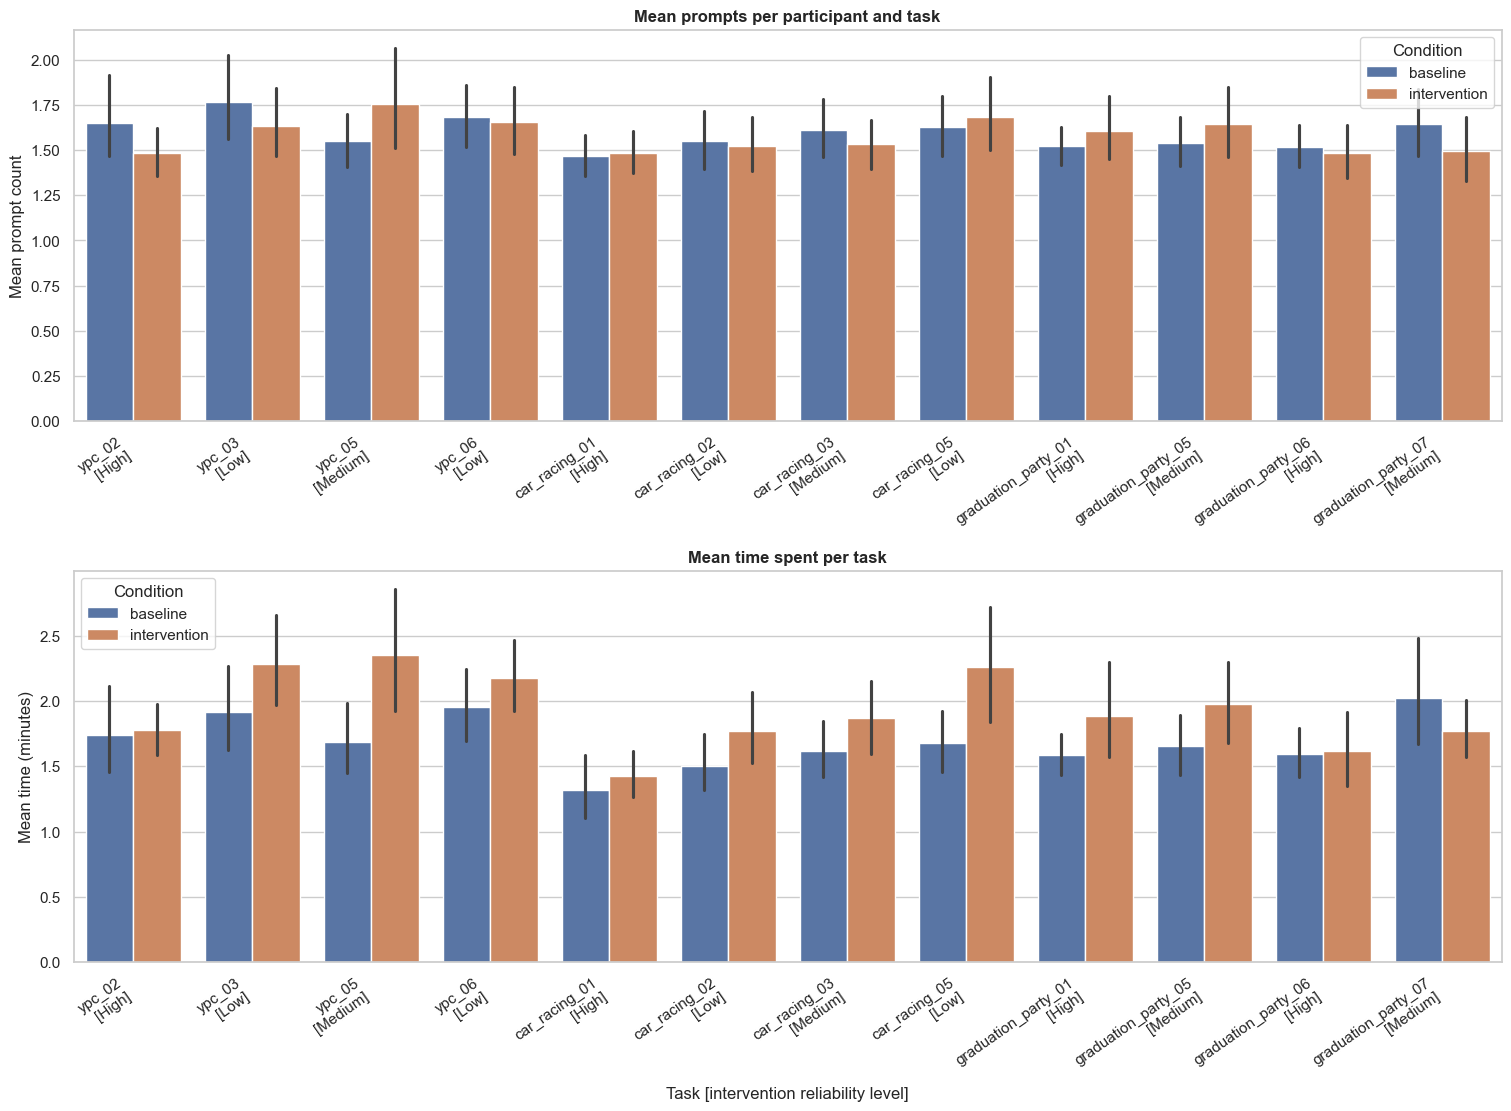

In [16]:
# Reliability levels configured for authored main tasks 6–17.
# Baseline participants did not see these labels; the column identifies the
# level shown to intervention participants on the corresponding task.
RELIABILITY_BY_TASK = dict(zip(
    TASK_NAMES,
    ["High", "Low", "Medium", "Low", "High", "Low",
     "Medium", "Low", "High", "Medium", "High", "Medium"],
))


def task_page_duration_seconds(record, task_id):
    """Time from entering a main-task page until entering the next page."""
    all_tasks = dict(task_items(record))
    current = all_tasks.get(task_id, {})
    current_index = number(current.get("displayIndex"))
    start = parse_time(current.get("ts"))
    if not math.isfinite(current_index) or not math.isfinite(start):
        return math.nan

    following_pages = []
    for task in all_tasks.values():
        display_index = number(task.get("displayIndex"))
        entered_at = parse_time(task.get("ts"))
        if (
            math.isfinite(display_index)
            and display_index > current_index
            and math.isfinite(entered_at)
        ):
            following_pages.append((display_index, entered_at))
    if not following_pages:
        return math.nan

    end = min(following_pages, key=lambda item: item[0])[1]
    return end - start if end >= start else math.nan


# Build one row for every participant × main task. Starting from task rows
# ensures that participants with zero prompts remain in the analysis.
included_ids = set(eligible["participant_id"])
task_participant = tasks[tasks["participant_id"].isin(included_ids)].copy()

duration_rows = []
for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in included_ids:
        continue
    for task_id, task_name in zip(main_task_ids(record), TASK_NAMES):
        duration_rows.append({
            "participant_id": participant_id,
            "task_id": task_id,
            "task_name": task_name,
            "task_seconds": task_page_duration_seconds(record, task_id),
        })
durations = pd.DataFrame(duration_rows)

prompt_counts = (
    prompts[prompts["participant_id"].isin(included_ids)]
    .groupby(["participant_id", "task_id"])
    .size()
    .rename("prompt_count")
    .reset_index()
)

task_participant = task_participant.merge(
    durations,
    on=["participant_id", "task_id", "task_name"],
    how="left",
)
task_participant = task_participant.merge(
    prompt_counts,
    on=["participant_id", "task_id"],
    how="left",
)
task_participant["prompt_count"] = task_participant["prompt_count"].fillna(0).astype(int)
task_participant["task_minutes"] = task_participant["task_seconds"] / 60
task_participant["reliability_level_intervention"] = task_participant[
    "task_name"
].map(RELIABILITY_BY_TASK)

task_level_summary = (
    task_participant
    .groupby(
        ["authored_order", "task_name", "reliability_level_intervention",
         "condition_group"],
        as_index=False,
    )
    .agg(
        participants=("participant_id", "nunique"),
        total_prompts=("prompt_count", "sum"),
        mean_prompts_per_participant=("prompt_count", "mean"),
        tasks_with_more_than_one_prompt_percent=(
            "prompt_count", lambda values: 100 * (values > 1).mean()
        ),
        mean_time_minutes=("task_minutes", "mean"),
        median_time_minutes=("task_minutes", "median"),
        accuracy_percent=("correct", lambda values: 100 * values.mean()),
        mean_confidence=("confidence", "mean"),
    )
    .sort_values(["authored_order", "condition_group"])
)

display(
    task_level_summary.style
    .format({
        "mean_prompts_per_participant": "{:.2f}",
        "tasks_with_more_than_one_prompt_percent": "{:.1f}%",
        "mean_time_minutes": "{:.2f}",
        "median_time_minutes": "{:.2f}",
        "accuracy_percent": "{:.1f}%",
        "mean_confidence": "{:.2f}",
    })
    .hide(axis="index")
)

# Explicit baseline-versus-intervention time comparison for each task.
task_time_rows = []
for authored_order, task_name in enumerate(TASK_NAMES, start=1):
    baseline_time = pd.to_numeric(
        task_participant.loc[
            (task_participant["task_name"] == task_name)
            & (task_participant["condition_group"] == "baseline"),
            "task_minutes",
        ],
        errors="coerce",
    ).dropna()
    intervention_time = pd.to_numeric(
        task_participant.loc[
            (task_participant["task_name"] == task_name)
            & (task_participant["condition_group"] == "intervention"),
            "task_minutes",
        ],
        errors="coerce",
    ).dropna()

    if len(baseline_time) >= 2 and len(intervention_time) >= 2:
        time_test = stats.ttest_ind(
            intervention_time, baseline_time, equal_var=False
        )
        welch_t = time_test.statistic
        two_sided_p = time_test.pvalue
    else:
        welch_t = math.nan
        two_sided_p = math.nan

    task_time_rows.append({
        "task_order": authored_order,
        "task_name": task_name,
        "reliability_level_intervention": RELIABILITY_BY_TASK[task_name],
        "baseline_n": len(baseline_time),
        "baseline_mean_minutes": baseline_time.mean(),
        "baseline_median_minutes": baseline_time.median(),
        "intervention_n": len(intervention_time),
        "intervention_mean_minutes": intervention_time.mean(),
        "intervention_median_minutes": intervention_time.median(),
        "difference_minutes_intervention_minus_baseline": (
            intervention_time.mean() - baseline_time.mean()
        ),
        "welch_t": welch_t,
        "two_sided_p": two_sided_p,
    })

task_time_comparison = pd.DataFrame(task_time_rows)
display(
    task_time_comparison.style
    .format({
        "baseline_mean_minutes": "{:.2f}",
        "baseline_median_minutes": "{:.2f}",
        "intervention_mean_minutes": "{:.2f}",
        "intervention_median_minutes": "{:.2f}",
        "difference_minutes_intervention_minus_baseline": "{:+.2f}",
        "welch_t": "{:.3f}",
        "two_sided_p": "{:.4g}",
    })
    .hide(axis="index")
)

# Side-by-side task comparisons. Labels show the reliability level used in
# the intervention condition.
plot_order = TASK_NAMES
task_labels = [
    f"{name}\n[{RELIABILITY_BY_TASK[name]}]" for name in plot_order
]
fig, axes = plt.subplots(2, 1, figsize=(15, 11), constrained_layout=True)

sns.barplot(
    data=task_participant,
    x="task_name", y="prompt_count", hue="condition_group",
    order=plot_order, hue_order=["baseline", "intervention"],
    errorbar=("ci", 95), ax=axes[0],
)
axes[0].set_title("Mean prompts per participant and task", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean prompt count")
axes[0].set_xticks(range(len(task_labels)), task_labels, rotation=35, ha="right")
axes[0].legend(title="Condition")

sns.barplot(
    data=task_participant,
    x="task_name", y="task_minutes", hue="condition_group",
    order=plot_order, hue_order=["baseline", "intervention"],
    errorbar=("ci", 95), ax=axes[1],
)
axes[1].set_title("Mean time spent per task", fontweight="bold")
axes[1].set_xlabel("Task [intervention reliability level]")
axes[1].set_ylabel("Mean time (minutes)")
axes[1].set_xticks(range(len(task_labels)), task_labels, rotation=35, ha="right")
axes[1].legend(title="Condition")
plt.show()


### H. Exploratory regression: reliability level and task time

Model 1 estimates the descriptive association between reliability level and time among intervention participants. Because each task has one fixed reliability level, this association is confounded with task difficulty. Model 2 uses both conditions, controls for task fixed effects, and estimates the intervention–baseline time difference separately for Low, Medium, and High reliability tasks. Both models use participant-clustered standard errors.

Model 1: reliability level and time within intervention


comparison,estimate_minutes,std_error,p_value
Low reliability (intercept),+2.123,0.117,4.787e-73
Medium minus Low,-0.130,0.108,0.2289
High minus Low,-0.445,0.089,6.489e-07


Model 2: intervention–baseline time difference by reliability level


reliability_level,intervention_minus_baseline_minutes,clustered_standard_error,95_ci_low,95_ci_high,p_value
Low,+0.362,0.152,+0.064,+0.659,0.01719
Medium,+0.248,0.150,-0.046,+0.543,0.09832
High,+0.120,0.116,-0.107,+0.347,0.3007


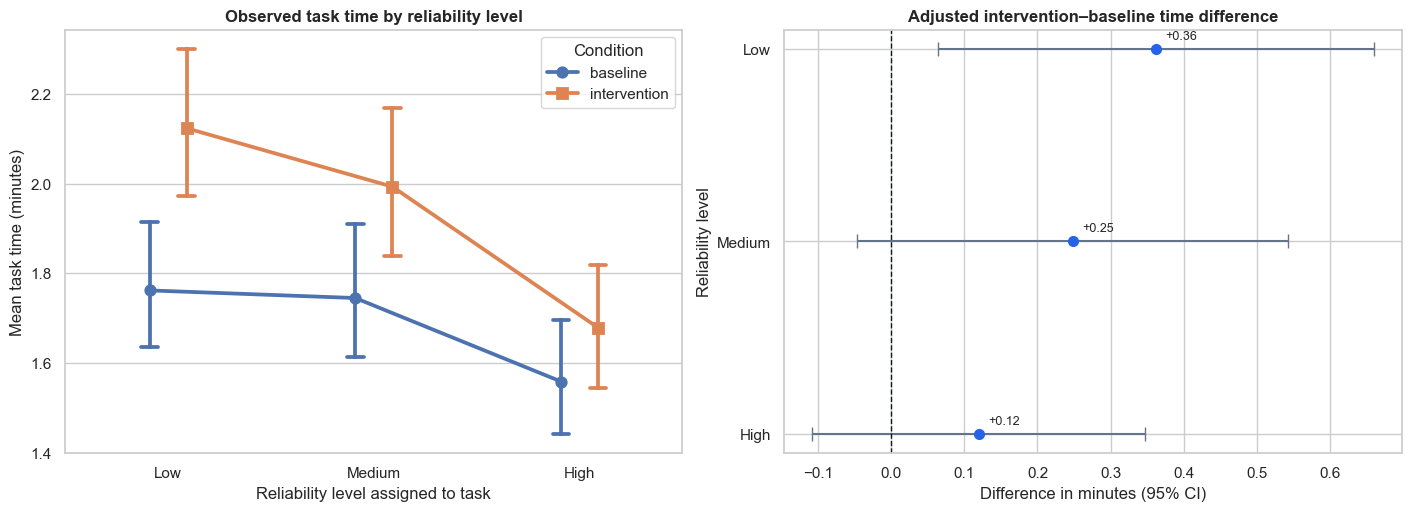

                            OLS Regression Results                            
Dep. Variable:           task_minutes   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     15.37
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           8.17e-07
Time:                        15:57:14   Log-Likelihood:                -3966.8
No. Observations:                1872   AIC:                             7940.
Df Residuals:                    1869   BIC:                             7956.
Df Model:                           2                                         
Covariance Type:              cluster                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [17]:
import statsmodels.formula.api as smf

REGRESSION_RELIABILITY_BY_TASK = dict(zip(
    TASK_NAMES,
    ["High", "Low", "Medium", "Low", "High", "Low",
     "Medium", "Low", "High", "Medium", "High", "Medium"],
))


def regression_task_duration_seconds(record, task_id):
    all_tasks = dict(task_items(record))
    current = all_tasks.get(task_id, {})
    current_index = number(current.get("displayIndex"))
    start = parse_time(current.get("ts"))
    if not math.isfinite(current_index) or not math.isfinite(start):
        return math.nan

    following = []
    for task in all_tasks.values():
        display_index = number(task.get("displayIndex"))
        entered_at = parse_time(task.get("ts"))
        if (
            math.isfinite(display_index)
            and display_index > current_index
            and math.isfinite(entered_at)
        ):
            following.append((display_index, entered_at))
    if not following:
        return math.nan
    end = min(following, key=lambda item: item[0])[1]
    return end - start if end >= start else math.nan


included_ids = set(eligible["participant_id"])
regression_duration_rows = []
for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in included_ids:
        continue
    for task_id, task_name in zip(main_task_ids(record), TASK_NAMES):
        regression_duration_rows.append({
            "participant_id": participant_id,
            "task_id": task_id,
            "task_name": task_name,
            "task_minutes": regression_task_duration_seconds(record, task_id) / 60,
        })

reliability_time_data = (
    tasks[tasks["participant_id"].isin(included_ids)][
        ["participant_id", "condition_group", "task_id", "task_name"]
    ]
    .merge(
        pd.DataFrame(regression_duration_rows),
        on=["participant_id", "task_id", "task_name"],
        how="left",
    )
)
reliability_time_data["reliability_level"] = reliability_time_data[
    "task_name"
].map(REGRESSION_RELIABILITY_BY_TASK)
reliability_time_data["intervention"] = (
    reliability_time_data["condition_group"] == "intervention"
).astype(int)
reliability_time_data["reliability_level"] = pd.Categorical(
    reliability_time_data["reliability_level"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
reliability_time_data = reliability_time_data.dropna(
    subset=["task_minutes", "reliability_level"]
).copy()

# Model 1: descriptive association within intervention participants.
# Standard errors are clustered by participant. Reliability level is fixed by
# task, so these coefficients may also reflect differences between the tasks
# assigned to each level.
intervention_only = reliability_time_data[
    reliability_time_data["intervention"] == 1
].copy()
association_model = smf.ols(
    "task_minutes ~ C(reliability_level, Treatment(reference='Low'))",
    data=intervention_only,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": intervention_only["participant_id"]},
)

association_rows = [{
    "comparison": "Low reliability (intercept)",
    "estimate_minutes": association_model.params["Intercept"],
    "std_error": association_model.bse["Intercept"],
    "p_value": association_model.pvalues["Intercept"],
}]
for level in ["Medium", "High"]:
    term = (
        "C(reliability_level, Treatment(reference='Low'))"
        f"[T.{level}]"
    )
    association_rows.append({
        "comparison": f"{level} minus Low",
        "estimate_minutes": association_model.params.get(term, math.nan),
        "std_error": association_model.bse.get(term, math.nan),
        "p_value": association_model.pvalues.get(term, math.nan),
    })
association_results = pd.DataFrame(association_rows)

print("Model 1: reliability level and time within intervention")
display(
    association_results.style
    .format({
        "estimate_minutes": "{:+.3f}",
        "std_error": "{:.3f}",
        "p_value": "{:.4g}",
    })
    .hide(axis="index")
)

# Model 2: condition difference at each reliability level, controlling for
# the identity of the specific task. Each coefficient is intervention minus
# baseline in minutes for that reliability level. Clustered participant SEs
# account for the 12 repeated task observations per person.
moderation_model = smf.ols(
    "task_minutes ~ 0 + C(task_name) + "
    "intervention:C(reliability_level)",
    data=reliability_time_data,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reliability_time_data["participant_id"]},
)

moderation_rows = []
for level in ["Low", "Medium", "High"]:
    term = f"intervention:C(reliability_level)[{level}]"
    estimate = moderation_model.params.get(term, math.nan)
    standard_error = moderation_model.bse.get(term, math.nan)
    p_value = moderation_model.pvalues.get(term, math.nan)
    moderation_rows.append({
        "reliability_level": level,
        "intervention_minus_baseline_minutes": estimate,
        "clustered_standard_error": standard_error,
        "95_ci_low": estimate - 1.96 * standard_error,
        "95_ci_high": estimate + 1.96 * standard_error,
        "p_value": p_value,
    })
moderation_results = pd.DataFrame(moderation_rows)

print("Model 2: intervention–baseline time difference by reliability level")
display(
    moderation_results.style
    .format({
        "intervention_minus_baseline_minutes": "{:+.3f}",
        "clustered_standard_error": "{:.3f}",
        "95_ci_low": "{:+.3f}",
        "95_ci_high": "{:+.3f}",
        "p_value": "{:.4g}",
    })
    .hide(axis="index")
)

# Regression visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Raw condition means with 95% confidence intervals.
sns.pointplot(
    data=reliability_time_data,
    x="reliability_level",
    y="task_minutes",
    hue="condition_group",
    hue_order=["baseline", "intervention"],
    order=["Low", "Medium", "High"],
    errorbar=("ci", 95),
    dodge=0.18,
    markers=["o", "s"],
    capsize=0.08,
    ax=axes[0],
)
axes[0].set_title("Observed task time by reliability level", fontweight="bold")
axes[0].set_xlabel("Reliability level assigned to task")
axes[0].set_ylabel("Mean task time (minutes)")
axes[0].legend(title="Condition")

# Adjusted coefficients from Model 2. Positive values mean that intervention
# participants spent longer than baseline participants.
plot_results = moderation_results.iloc[::-1].reset_index(drop=True)
y_positions = range(len(plot_results))
lower_error = (
    plot_results["intervention_minus_baseline_minutes"]
    - plot_results["95_ci_low"]
)
upper_error = (
    plot_results["95_ci_high"]
    - plot_results["intervention_minus_baseline_minutes"]
)
axes[1].errorbar(
    plot_results["intervention_minus_baseline_minutes"],
    y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=5,
    markersize=7,
)
axes[1].axvline(0, color="#111827", linestyle="--", linewidth=1)
axes[1].set_yticks(list(y_positions), plot_results["reliability_level"])
axes[1].set_title(
    "Adjusted intervention–baseline time difference",
    fontweight="bold",
)
axes[1].set_xlabel("Difference in minutes (95% CI)")
axes[1].set_ylabel("Reliability level")

for position, row in plot_results.iterrows():
    axes[1].annotate(
        f"{row['intervention_minus_baseline_minutes']:+.2f}",
        (row["intervention_minus_baseline_minutes"], position),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
    )

plt.show()

print(association_model.summary())
print(moderation_model.summary())


### I. Pre/post performance estimates and perceived AI ability

This section analyzes participants’ expected and retrospective estimates of performance with AI, without AI, and by the AI alone. Scores are reported both out of 12 and as percentages. The separate perceived-AI-ability item is measured directly from 0% to 100%.

estimate,time,condition,n,mean_out_of_12,sd,median_out_of_12,mean_percent_of_12
Participant with AI,Before,baseline,178,10.20,1.90,10.00,85.0%
Participant with AI,Before,intervention,156,9.79,2.47,10.00,81.6%
Participant with AI,Before,overall,334,10.01,2.19,10.00,83.4%
Participant with AI,After,baseline,178,9.75,2.29,10.00,81.3%
Participant with AI,After,intervention,156,8.14,2.17,8.00,67.8%
Participant with AI,After,overall,334,9.00,2.37,9.00,75.0%
Participant without AI,Before,baseline,178,6.79,2.89,7.00,56.6%
Participant without AI,Before,intervention,156,6.49,3.03,6.00,54.1%
Participant without AI,Before,overall,334,6.65,2.96,7.00,55.4%
Participant without AI,After,baseline,178,5.35,3.20,5.00,44.6%


estimate,comparison,n,mean_before,mean_after,mean_change,test_statistic,two_sided_p
Participant with AI,After − before within baseline,178,10.20,9.75,-0.44,-2.373,0.01871
Participant with AI,After − before within intervention,156,9.79,8.14,-1.65,-7.457,5.874e-12
Participant with AI,Change: intervention − baseline,334,nan,nan,-1.21,-4.171,3.927e-05
Participant without AI,After − before within baseline,178,6.79,5.35,-1.43,-7.613,1.541e-12
Participant without AI,After − before within intervention,156,6.49,4.96,-1.53,-6.869,1.477e-10
Participant without AI,Change: intervention − baseline,334,nan,nan,-0.09,-0.320,0.7494
AI alone,After − before within baseline,178,9.79,9.35,-0.44,-2.177,0.03083
AI alone,After − before within intervention,156,9.13,7.63,-1.49,-5.553,1.189e-07
AI alone,Change: intervention − baseline,334,nan,nan,-1.05,-3.110,0.002049


condition,n,mean_percent,sd,median_percent,q1,q3
baseline,178,68.3%,21.30,71.0%,51.0%,83.8%
intervention,156,65.5%,21.44,68.5%,50.0%,84.2%
overall,334,67.0%,21.38,70.0%,50.0%,84.0%


Perceived AI planning ability: intervention M=65.54% (n=156), baseline M=68.26% (n=178), Welch t=-1.160, two-sided p=0.24691


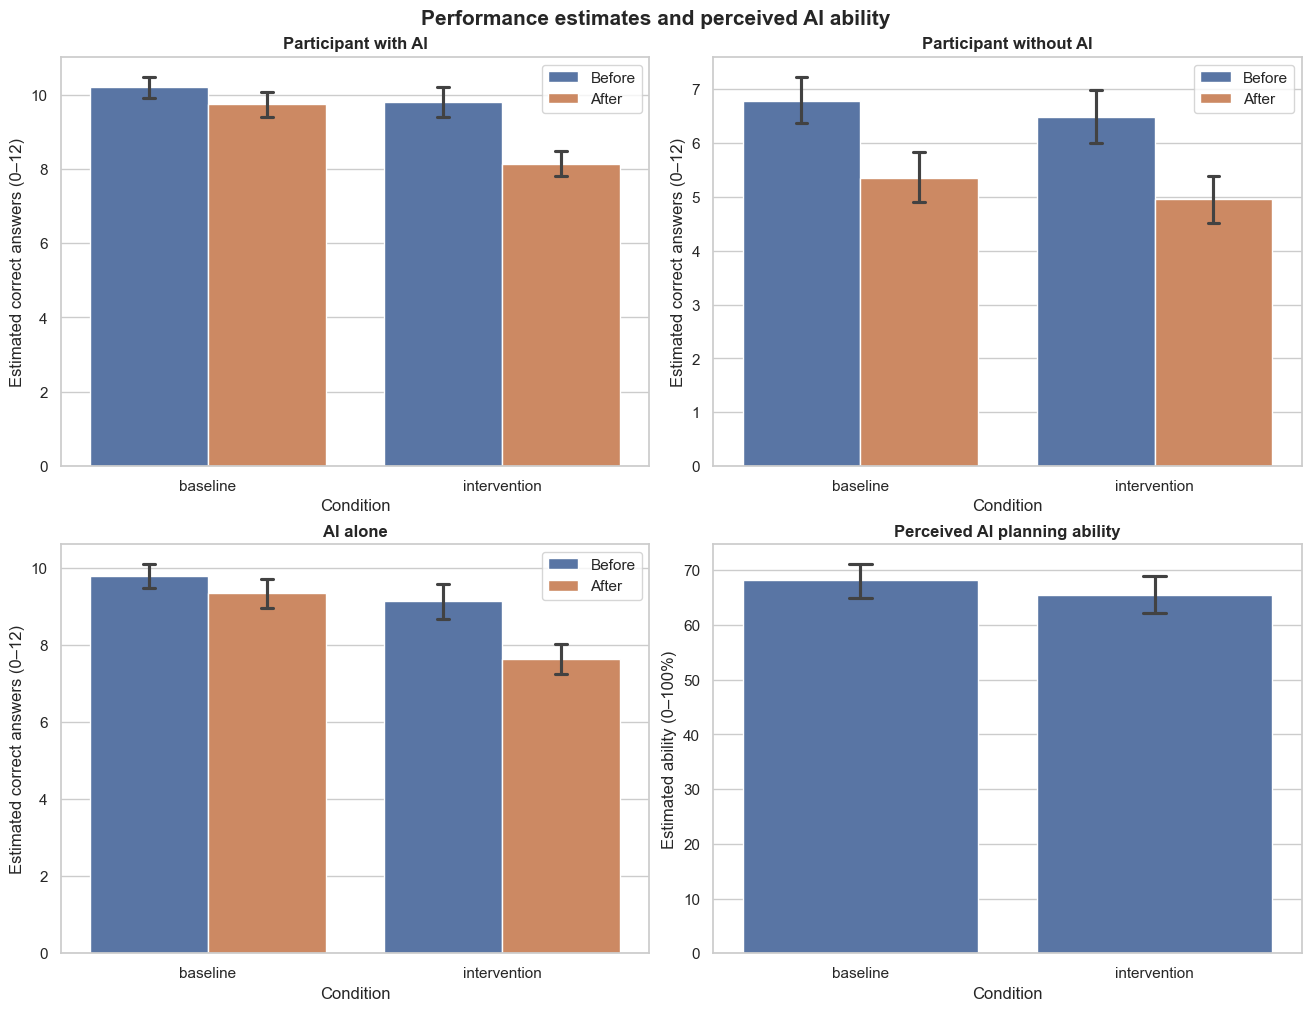

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

ESTIMATION_PATTERNS = {
    "with_ai_pre": r"using the AI, how many of the 12.*think you would solve correctly",
    "with_ai_post": r"using the AI, how many of the 12.*think you have solved correctly",
    "without_ai_pre": r"without AI use, how many of the 12.*think you would solve correctly",
    "without_ai_post": r"without AI use, how many of the 12.*think you would have solved correctly",
    "ai_alone_pre": r"on its own, how many of the 12.*think the AI would solve correctly",
    "ai_alone_post": r"on its own, how many of the 12.*think the AI would have solved correctly",
    "ai_planning_ability_percent": (
        r"compared to other AI systems.*planning and organizing ability"
    ),
}

eligible_ids = set(eligible["participant_id"])
condition_lookup = eligible.set_index("participant_id")["condition_group"].to_dict()
estimation_rows = []
for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in eligible_ids:
        continue
    row = {
        "participant_id": participant_id,
        "condition_group": condition_lookup[participant_id],
    }
    for variable, pattern in ESTIMATION_PATTERNS.items():
        row[variable] = number(find_response(record, pattern))
    estimation_rows.append(row)

estimation_data = pd.DataFrame(estimation_rows)

ESTIMATE_LABELS = {
    "with_ai": "Participant with AI",
    "without_ai": "Participant without AI",
    "ai_alone": "AI alone",
}

# Descriptives for every pre/post estimate. Percentages express the estimated
# number correct as a proportion of the 12 main tasks.
estimate_descriptive_rows = []
for construct, label in ESTIMATE_LABELS.items():
    for timepoint in ["pre", "post"]:
        variable = f"{construct}_{timepoint}"
        for condition in ["baseline", "intervention", "overall"]:
            group = (
                estimation_data
                if condition == "overall"
                else estimation_data[
                    estimation_data["condition_group"] == condition
                ]
            )
            values = pd.to_numeric(group[variable], errors="coerce").dropna()
            estimate_descriptive_rows.append({
                "estimate": label,
                "time": "Before" if timepoint == "pre" else "After",
                "condition": condition,
                "n": len(values),
                "mean_out_of_12": values.mean(),
                "sd": values.std(),
                "median_out_of_12": values.median(),
                "mean_percent_of_12": 100 * values.mean() / 12,
            })

estimate_descriptives = pd.DataFrame(estimate_descriptive_rows)
display(
    estimate_descriptives.style
    .format({
        "mean_out_of_12": "{:.2f}",
        "sd": "{:.2f}",
        "median_out_of_12": "{:.2f}",
        "mean_percent_of_12": "{:.1f}%",
    })
    .hide(axis="index")
)

# Paired pre/post change within each condition and Welch comparison of change
# scores between conditions.
change_test_rows = []
for construct, label in ESTIMATE_LABELS.items():
    pre, post = f"{construct}_pre", f"{construct}_post"
    estimation_data[f"{construct}_change"] = (
        estimation_data[post] - estimation_data[pre]
    )
    for condition in ["baseline", "intervention"]:
        paired = estimation_data.loc[
            estimation_data["condition_group"] == condition,
            [pre, post],
        ].apply(pd.to_numeric, errors="coerce").dropna()
        paired_test = (
            stats.ttest_rel(paired[post], paired[pre])
            if len(paired) >= 2
            else None
        )
        change_test_rows.append({
            "estimate": label,
            "comparison": f"After − before within {condition}",
            "n": len(paired),
            "mean_before": paired[pre].mean(),
            "mean_after": paired[post].mean(),
            "mean_change": (paired[post] - paired[pre]).mean(),
            "test_statistic": paired_test.statistic if paired_test else math.nan,
            "two_sided_p": paired_test.pvalue if paired_test else math.nan,
        })

    baseline_change = pd.to_numeric(
        estimation_data.loc[
            estimation_data["condition_group"] == "baseline",
            f"{construct}_change",
        ],
        errors="coerce",
    ).dropna()
    intervention_change = pd.to_numeric(
        estimation_data.loc[
            estimation_data["condition_group"] == "intervention",
            f"{construct}_change",
        ],
        errors="coerce",
    ).dropna()
    change_test = stats.ttest_ind(
        intervention_change, baseline_change, equal_var=False
    )
    change_test_rows.append({
        "estimate": label,
        "comparison": "Change: intervention − baseline",
        "n": len(intervention_change) + len(baseline_change),
        "mean_before": math.nan,
        "mean_after": math.nan,
        "mean_change": intervention_change.mean() - baseline_change.mean(),
        "test_statistic": change_test.statistic,
        "two_sided_p": change_test.pvalue,
    })

estimate_change_tests = pd.DataFrame(change_test_rows)
display(
    estimate_change_tests.style
    .format({
        "mean_before": "{:.2f}",
        "mean_after": "{:.2f}",
        "mean_change": "{:+.2f}",
        "test_statistic": "{:.3f}",
        "two_sided_p": "{:.4g}",
    })
    .hide(axis="index")
)

# The direct percentage rating of the AI's planning and organizing ability.
ability_rows = []
for condition in ["baseline", "intervention", "overall"]:
    group = (
        estimation_data
        if condition == "overall"
        else estimation_data[estimation_data["condition_group"] == condition]
    )
    values = pd.to_numeric(
        group["ai_planning_ability_percent"], errors="coerce"
    ).dropna()
    ability_rows.append({
        "condition": condition,
        "n": len(values),
        "mean_percent": values.mean(),
        "sd": values.std(),
        "median_percent": values.median(),
        "q1": values.quantile(.25),
        "q3": values.quantile(.75),
    })

ai_ability_descriptives = pd.DataFrame(ability_rows)
display(
    ai_ability_descriptives.style
    .format({
        "mean_percent": "{:.1f}%",
        "sd": "{:.2f}",
        "median_percent": "{:.1f}%",
        "q1": "{:.1f}%",
        "q3": "{:.1f}%",
    })
    .hide(axis="index")
)

ability_baseline = pd.to_numeric(
    estimation_data.loc[
        estimation_data["condition_group"] == "baseline",
        "ai_planning_ability_percent",
    ],
    errors="coerce",
).dropna()
ability_intervention = pd.to_numeric(
    estimation_data.loc[
        estimation_data["condition_group"] == "intervention",
        "ai_planning_ability_percent",
    ],
    errors="coerce",
).dropna()
ability_test = stats.ttest_ind(
    ability_intervention, ability_baseline, equal_var=False
)
print(
    "Perceived AI planning ability: "
    f"intervention M={ability_intervention.mean():.2f}% "
    f"(n={len(ability_intervention)}), "
    f"baseline M={ability_baseline.mean():.2f}% "
    f"(n={len(ability_baseline)}), "
    f"Welch t={ability_test.statistic:.3f}, "
    f"two-sided p={ability_test.pvalue:.5g}"
)

# Visualization of pre/post estimates and the direct percentage rating.
estimate_long = estimation_data.melt(
    id_vars=["participant_id", "condition_group"],
    value_vars=[
        "with_ai_pre", "with_ai_post",
        "without_ai_pre", "without_ai_post",
        "ai_alone_pre", "ai_alone_post",
    ],
    var_name="measure",
    value_name="estimated_correct",
)
estimate_long["construct"] = estimate_long["measure"].str.replace(
    r"_(pre|post)$", "", regex=True
).map(ESTIMATE_LABELS)
estimate_long["time"] = estimate_long["measure"].str.extract(
    r"_(pre|post)$"
)[0].map({"pre": "Before", "post": "After"})

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for axis, construct in zip(
    axes.flat[:3], ["Participant with AI", "Participant without AI", "AI alone"]
):
    sns.barplot(
        data=estimate_long[estimate_long["construct"] == construct],
        x="condition_group",
        y="estimated_correct",
        hue="time",
        order=["baseline", "intervention"],
        hue_order=["Before", "After"],
        errorbar=("ci", 95),
        capsize=.08,
        ax=axis,
    )
    axis.set_title(construct, fontweight="bold")
    axis.set_xlabel("Condition")
    axis.set_ylabel("Estimated correct answers (0–12)")
    axis.legend(title="")

sns.barplot(
    data=estimation_data,
    x="condition_group",
    y="ai_planning_ability_percent",
    order=["baseline", "intervention"],
    errorbar=("ci", 95),
    capsize=.08,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Perceived AI planning ability", fontweight="bold")
axes[1, 1].set_xlabel("Condition")
axes[1, 1].set_ylabel("Estimated ability (0–100%)")
fig.suptitle(
    "Performance estimates and perceived AI ability",
    fontsize=15,
    fontweight="bold",
)
plt.show()


### J. System Usability Scale (SUS)

The ten SUS items are scored on the standard 0–100 scale. For positively worded odd-numbered items, 1 is subtracted from the response; for negatively worded even-numbered items, the response is subtracted from 5. The ten contributions are summed and multiplied by 2.5. Higher values indicate greater perceived usability.

condition,n,mean,sd,median,q1,q3,minimum,maximum
baseline,178,68.17,11.66,70.00,62.50,77.50,20.00,90.00
intervention,156,65.00,10.87,67.50,57.50,75.00,32.50,80.00
overall,334,66.69,11.40,67.50,60.00,75.00,20.00,90.00


condition,complete_n,cronbach_alpha
baseline,178,0.595
intervention,156,0.488
overall,334,0.551


baseline_n,baseline_mean,intervention_n,intervention_mean,difference_intervention_minus_baseline,welch_t,two_sided_p
178,68.17,156,65.00,-3.17,-2.573,0.01053


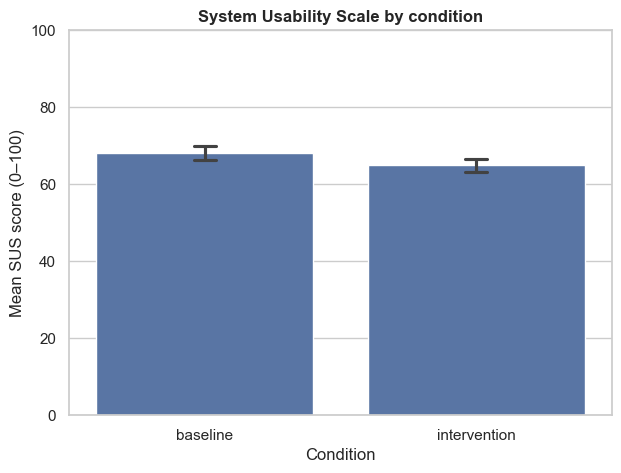

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

SUS_ITEM_LABELS = [
    "Would like to use frequently",
    "Unnecessarily complex",
    "Easy to use",
    "Need technical support",
    "Functions well integrated",
    "Too much inconsistency",
    "Most people learn quickly",
    "Very cumbersome",
    "Felt confident",
    "Needed to learn a lot",
]

def sus_item_scores(record):
    """Return direction-aligned SUS item contributions on the 0–4 scale."""
    _, sus_task = find_task(record, r"like to use this system frequently")
    if not sus_task:
        return [math.nan] * 10
    raw = [
        number(response.get("answer"))
        for response in responses(sus_task)
        if "reading this" not in norm(response.get("question"))
    ]
    if len(raw) != 10 or not all(math.isfinite(value) for value in raw):
        return [math.nan] * 10
    return [
        value - 1 if index % 2 == 0 else 5 - value
        for index, value in enumerate(raw)
    ]

def scale_alpha(frame):
    complete = frame.apply(pd.to_numeric, errors="coerce").dropna()
    k = complete.shape[1]
    if k < 2 or len(complete) < 2:
        return math.nan
    total_variance = complete.sum(axis=1).var(ddof=1)
    if not math.isfinite(total_variance) or total_variance == 0:
        return math.nan
    return k / (k - 1) * (
        1 - complete.var(axis=0, ddof=1).sum() / total_variance
    )

eligible_ids = set(eligible["participant_id"])
condition_lookup = eligible.set_index("participant_id")["condition_group"].to_dict()
sus_rows = []
for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in eligible_ids:
        continue
    contributions = sus_item_scores(record)
    row = {
        "participant_id": participant_id,
        "condition_group": condition_lookup[participant_id],
    }
    row.update({
        f"sus_item_{index + 1}": value
        for index, value in enumerate(contributions)
    })
    sus_rows.append(row)

sus_data = pd.DataFrame(sus_rows)
sus_item_columns = [f"sus_item_{index}" for index in range(1, 11)]
sus_data["sus_score"] = sus_data[sus_item_columns].sum(
    axis=1, min_count=10
) * 2.5

sus_descriptive_rows = []
sus_reliability_rows = []
for condition in ["baseline", "intervention", "overall"]:
    group = (
        sus_data
        if condition == "overall"
        else sus_data[sus_data["condition_group"] == condition]
    )
    values = pd.to_numeric(group["sus_score"], errors="coerce").dropna()
    sus_descriptive_rows.append({
        "condition": condition,
        "n": len(values),
        "mean": values.mean(),
        "sd": values.std(),
        "median": values.median(),
        "q1": values.quantile(.25),
        "q3": values.quantile(.75),
        "minimum": values.min(),
        "maximum": values.max(),
    })
    sus_reliability_rows.append({
        "condition": condition,
        "complete_n": len(group[sus_item_columns].dropna()),
        "cronbach_alpha": scale_alpha(group[sus_item_columns]),
    })

sus_descriptives = pd.DataFrame(sus_descriptive_rows)
display(
    sus_descriptives.style
    .format({
        "mean": "{:.2f}", "sd": "{:.2f}", "median": "{:.2f}",
        "q1": "{:.2f}", "q3": "{:.2f}",
        "minimum": "{:.2f}", "maximum": "{:.2f}",
    })
    .hide(axis="index")
)
display(
    pd.DataFrame(sus_reliability_rows).style
    .format({"cronbach_alpha": "{:.3f}"})
    .hide(axis="index")
)

sus_baseline = pd.to_numeric(
    sus_data.loc[sus_data["condition_group"] == "baseline", "sus_score"],
    errors="coerce",
).dropna()
sus_intervention = pd.to_numeric(
    sus_data.loc[sus_data["condition_group"] == "intervention", "sus_score"],
    errors="coerce",
).dropna()
sus_test = stats.ttest_ind(
    sus_intervention, sus_baseline, equal_var=False
)
sus_condition_test = pd.DataFrame([{
    "baseline_n": len(sus_baseline),
    "baseline_mean": sus_baseline.mean(),
    "intervention_n": len(sus_intervention),
    "intervention_mean": sus_intervention.mean(),
    "difference_intervention_minus_baseline": (
        sus_intervention.mean() - sus_baseline.mean()
    ),
    "welch_t": sus_test.statistic,
    "two_sided_p": sus_test.pvalue,
}])
display(
    sus_condition_test.style
    .format({
        "baseline_mean": "{:.2f}",
        "intervention_mean": "{:.2f}",
        "difference_intervention_minus_baseline": "{:+.2f}",
        "welch_t": "{:.3f}",
        "two_sided_p": "{:.4g}",
    })
    .hide(axis="index")
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=sus_data,
    x="condition_group",
    y="sus_score",
    order=["baseline", "intervention"],
    errorbar=("ci", 95),
    capsize=.08,
)
plt.ylim(0, 100)
plt.title("System Usability Scale by condition", fontweight="bold")
plt.xlabel("Condition")
plt.ylabel("Mean SUS score (0–100)")
plt.show()


### K. NASA Raw Task Load Index (NASA-TLX)

The six unweighted NASA-TLX dimensions are summarized as a Raw TLX score. In this study, each item ranges from 1 to 20. The success item is reverse-scored as `21 − response` so that higher values on every dimension and on the composite consistently indicate greater perceived workload. The composite is the mean of all six direction-aligned dimensions.

condition,n,mean,sd,median,q1,q3,minimum,maximum
baseline,178,7.62,3.27,7.67,5.21,9.62,1.00,16.00
intervention,156,9.17,2.84,9.00,7.46,10.88,1.83,17.17
overall,334,8.35,3.17,8.33,6.33,10.17,1.00,17.17


measure,baseline_n,baseline_mean,intervention_n,intervention_mean,difference_intervention_minus_baseline,welch_t,two_sided_p
Raw TLX composite,178,7.62,156,9.17,+1.55,4.647,4.856e-06
Mental demand,178,11.90,156,14.51,+2.61,4.467,1.091e-05
Physical demand,178,4.55,156,4.74,+0.19,0.367,0.7136
Temporal demand,178,6.48,156,6.64,+0.16,0.314,0.7536
Performance demand (reversed),178,6.09,156,8.16,+2.07,4.396,1.513e-05
Effort,178,10.81,156,12.94,+2.12,3.841,0.0001473
Frustration,178,5.89,156,8.06,+2.17,3.597,0.0003738


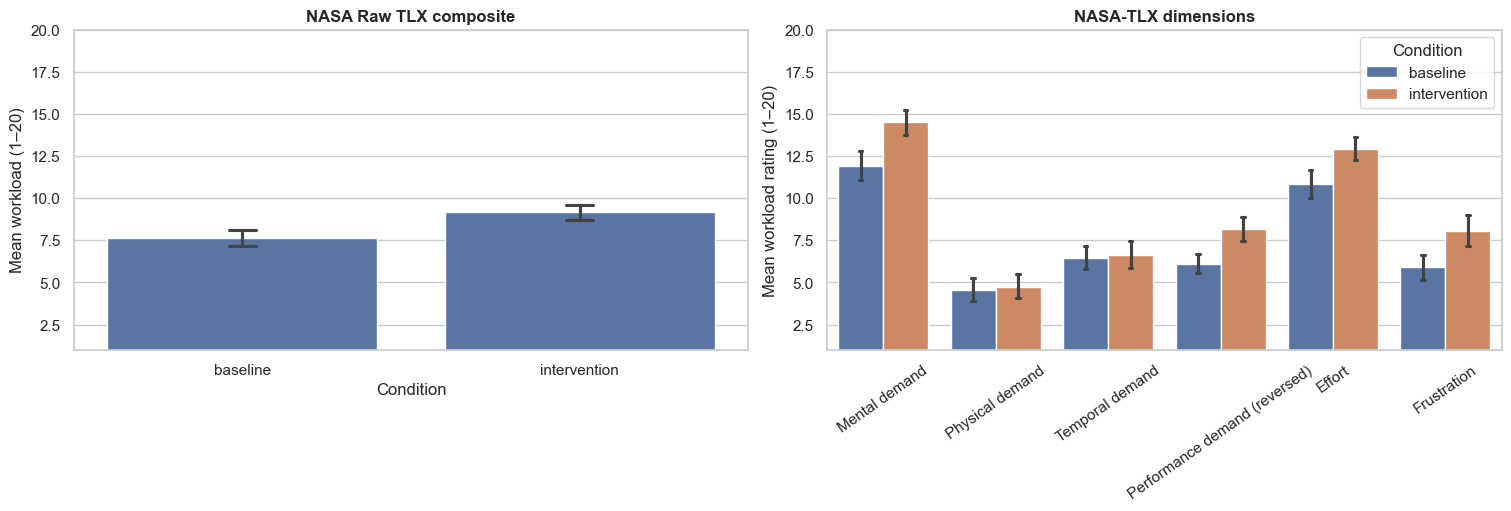

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

TLX_DIMENSIONS = [
    "Mental demand",
    "Physical demand",
    "Temporal demand",
    "Performance demand (reversed)",
    "Effort",
    "Frustration",
]

def tlx_item_scores(record):
    """Return six NASA Raw TLX dimensions, all oriented high=more workload."""
    _, tlx_task = find_task(record, r"mentally demanding")
    raw = [
        number(response.get("answer"))
        for response in responses(tlx_task or {})
    ]
    if len(raw) != 6 or not all(math.isfinite(value) for value in raw):
        return [math.nan] * 6
    raw[3] = 21 - raw[3]
    return raw

eligible_ids = set(eligible["participant_id"])
condition_lookup = eligible.set_index("participant_id")["condition_group"].to_dict()
tlx_rows = []
for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in eligible_ids:
        continue
    dimensions = tlx_item_scores(record)
    row = {
        "participant_id": participant_id,
        "condition_group": condition_lookup[participant_id],
    }
    row.update({
        f"tlx_item_{index + 1}": value
        for index, value in enumerate(dimensions)
    })
    tlx_rows.append(row)

tlx_data = pd.DataFrame(tlx_rows)
tlx_item_columns = [f"tlx_item_{index}" for index in range(1, 7)]
tlx_data["raw_tlx_mean"] = tlx_data[tlx_item_columns].mean(
    axis=1, skipna=False
)

tlx_descriptive_rows = []
for condition in ["baseline", "intervention", "overall"]:
    group = (
        tlx_data
        if condition == "overall"
        else tlx_data[tlx_data["condition_group"] == condition]
    )
    values = pd.to_numeric(group["raw_tlx_mean"], errors="coerce").dropna()
    tlx_descriptive_rows.append({
        "condition": condition,
        "n": len(values),
        "mean": values.mean(),
        "sd": values.std(),
        "median": values.median(),
        "q1": values.quantile(.25),
        "q3": values.quantile(.75),
        "minimum": values.min(),
        "maximum": values.max(),
    })

tlx_descriptives = pd.DataFrame(tlx_descriptive_rows)
display(
    tlx_descriptives.style
    .format({
        "mean": "{:.2f}", "sd": "{:.2f}", "median": "{:.2f}",
        "q1": "{:.2f}", "q3": "{:.2f}",
        "minimum": "{:.2f}", "maximum": "{:.2f}",
    })
    .hide(axis="index")
)

tlx_test_rows = []
tlx_test_definitions = {
    "Raw TLX composite": "raw_tlx_mean",
    **{
        label: column
        for label, column in zip(TLX_DIMENSIONS, tlx_item_columns)
    },
}
for label, column in tlx_test_definitions.items():
    baseline_values = pd.to_numeric(
        tlx_data.loc[
            tlx_data["condition_group"] == "baseline", column
        ],
        errors="coerce",
    ).dropna()
    intervention_values = pd.to_numeric(
        tlx_data.loc[
            tlx_data["condition_group"] == "intervention", column
        ],
        errors="coerce",
    ).dropna()
    test = stats.ttest_ind(
        intervention_values, baseline_values, equal_var=False
    )
    tlx_test_rows.append({
        "measure": label,
        "baseline_n": len(baseline_values),
        "baseline_mean": baseline_values.mean(),
        "intervention_n": len(intervention_values),
        "intervention_mean": intervention_values.mean(),
        "difference_intervention_minus_baseline": (
            intervention_values.mean() - baseline_values.mean()
        ),
        "welch_t": test.statistic,
        "two_sided_p": test.pvalue,
    })

tlx_condition_tests = pd.DataFrame(tlx_test_rows)
display(
    tlx_condition_tests.style
    .format({
        "baseline_mean": "{:.2f}",
        "intervention_mean": "{:.2f}",
        "difference_intervention_minus_baseline": "{:+.2f}",
        "welch_t": "{:.3f}",
        "two_sided_p": "{:.4g}",
    })
    .hide(axis="index")
)

tlx_long = tlx_data.melt(
    id_vars=["participant_id", "condition_group"],
    value_vars=tlx_item_columns,
    var_name="dimension_key",
    value_name="rating",
)
tlx_long["dimension"] = tlx_long["dimension_key"].map({
    column: label
    for column, label in zip(tlx_item_columns, TLX_DIMENSIONS)
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
sns.barplot(
    data=tlx_data,
    x="condition_group",
    y="raw_tlx_mean",
    order=["baseline", "intervention"],
    errorbar=("ci", 95),
    capsize=.08,
    ax=axes[0],
)
axes[0].set_title("NASA Raw TLX composite", fontweight="bold")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Mean workload (1–20)")
axes[0].set_ylim(1, 20)

sns.barplot(
    data=tlx_long,
    x="dimension",
    y="rating",
    hue="condition_group",
    hue_order=["baseline", "intervention"],
    errorbar=("ci", 95),
    capsize=.06,
    ax=axes[1],
)
axes[1].set_title("NASA-TLX dimensions", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean workload rating (1–20)")
axes[1].set_ylim(1, 20)
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="Condition")
plt.show()


### L. User Experience Questionnaire—Short (UEQ-S)

The UEQ-S is scored according to Schrepp, Hinderks, and Thomaschewski (2017). All eight items are oriented from the negative term on the left to the positive term on the right and transformed from 1–7 to −3–+3 by subtracting 4. Items 1–4 form Pragmatic Quality, items 5–8 form Hedonic Quality, and all eight items form the overall UEQ-S score. Source: [Design and Evaluation of a Short Version of the User Experience Questionnaire (UEQ-S)](https://d-nb.info/1353313050/34).

scale,condition,n,mean,sd,median,q1,q3,minimum,maximum
Pragmatic Quality,baseline,178,1.78,1.17,2.00,1.00,3.00,-2.25,3.00
Pragmatic Quality,intervention,156,1.46,1.13,1.50,0.50,2.25,-1.25,3.00
Pragmatic Quality,overall,334,1.63,1.16,2.00,0.75,2.50,-2.25,3.00
Hedonic Quality,baseline,178,0.84,1.27,1.00,0.00,1.75,-2.25,3.00
Hedonic Quality,intervention,156,0.51,1.33,0.50,-0.50,1.50,-2.50,3.00
Hedonic Quality,overall,334,0.69,1.31,0.75,-0.25,1.50,-2.50,3.00
Overall UEQ-S,baseline,178,1.31,1.08,1.38,0.62,2.00,-1.62,3.00
Overall UEQ-S,intervention,156,0.99,1.09,1.12,0.12,1.75,-1.50,3.00
Overall UEQ-S,overall,334,1.16,1.10,1.25,0.38,2.00,-1.62,3.00


scale,condition,complete_n,cronbach_alpha
Pragmatic Quality,baseline,178,0.830
Pragmatic Quality,intervention,156,0.845
Pragmatic Quality,overall,334,0.840
Hedonic Quality,baseline,178,0.871
Hedonic Quality,intervention,156,0.877
Hedonic Quality,overall,334,0.876
Overall UEQ-S,baseline,178,0.880
Overall UEQ-S,intervention,156,0.885
Overall UEQ-S,overall,334,0.885


scale,baseline_n,baseline_mean,intervention_n,intervention_mean,difference_intervention_minus_baseline,welch_t,two_sided_p
Pragmatic Quality,178,1.78,156,1.46,-0.32,-2.563,0.01082
Hedonic Quality,178,0.84,156,0.51,-0.33,-2.298,0.02218
Overall UEQ-S,178,1.31,156,0.99,-0.33,-2.732,0.006645


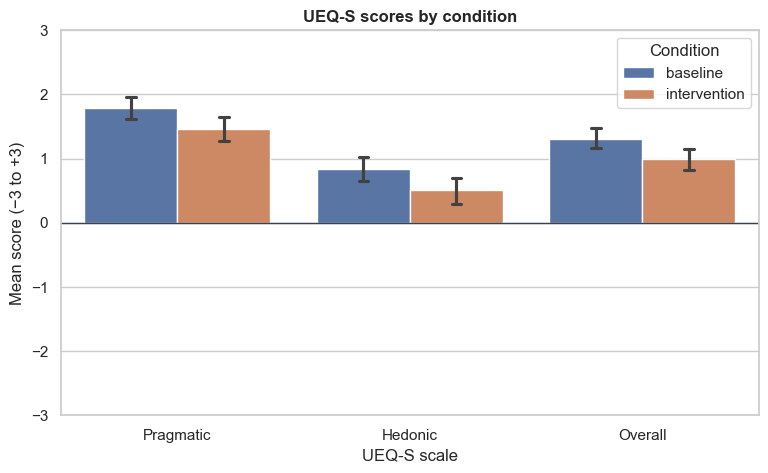

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

UEQS_ITEM_LABELS = [
    "obstructive–supportive",
    "complicated–easy",
    "inefficient–efficient",
    "confusing–clear",
    "boring–exciting",
    "not interesting–interesting",
    "conventional–inventive",
    "usual–leading edge",
]

def ueq_s_items(record):
    """Return the eight UEQ-S responses transformed to the −3 to +3 scale."""
    sus_id, _ = find_task(record, r"like to use this system frequently")
    task_map = dict(task_items(record))
    if sus_id is None or sus_id - 1 not in task_map:
        return [math.nan] * 8
    raw = [number(response.get("answer"))
           for response in responses(task_map[sus_id - 1])]
    if len(raw) != 8 or not all(math.isfinite(value) for value in raw):
        return [math.nan] * 8
    return [value - 4 for value in raw]


ueqs_item_rows = []
eligible_ids = set(eligible["participant_id"])
condition_lookup = eligible.set_index("participant_id")["condition_group"].to_dict()
for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in eligible_ids:
        continue
    values = ueq_s_items(record)
    row = {
        "participant_id": participant_id,
        "condition_group": condition_lookup[participant_id],
    }
    row.update({
        f"ueqs_item_{index + 1}": value
        for index, value in enumerate(values)
    })
    ueqs_item_rows.append(row)

ueqs_items = pd.DataFrame(ueqs_item_rows)
item_columns = [f"ueqs_item_{index}" for index in range(1, 9)]
pragmatic_items = item_columns[:4]
hedonic_items = item_columns[4:]
ueqs_items["ueq_s_pragmatic"] = ueqs_items[pragmatic_items].mean(
    axis=1, skipna=False
)
ueqs_items["ueq_s_hedonic"] = ueqs_items[hedonic_items].mean(
    axis=1, skipna=False
)
ueqs_items["ueq_s_overall"] = ueqs_items[item_columns].mean(
    axis=1, skipna=False
)

def cronbach_alpha(frame):
    """Cronbach's alpha using complete item responses."""
    complete = frame.apply(pd.to_numeric, errors="coerce").dropna()
    k = complete.shape[1]
    if k < 2 or len(complete) < 2:
        return math.nan
    total_variance = complete.sum(axis=1).var(ddof=1)
    if not math.isfinite(total_variance) or total_variance == 0:
        return math.nan
    return k / (k - 1) * (
        1 - complete.var(axis=0, ddof=1).sum() / total_variance
    )


ueqs_descriptive_rows = []
reliability_rows = []
scale_definitions = {
    "Pragmatic Quality": ("ueq_s_pragmatic", pragmatic_items),
    "Hedonic Quality": ("ueq_s_hedonic", hedonic_items),
    "Overall UEQ-S": ("ueq_s_overall", item_columns),
}
for scale_label, (scale_column, scale_items) in scale_definitions.items():
    for condition in ["baseline", "intervention", "overall"]:
        group = (
            ueqs_items
            if condition == "overall"
            else ueqs_items[ueqs_items["condition_group"] == condition]
        )
        values = pd.to_numeric(group[scale_column], errors="coerce").dropna()
        ueqs_descriptive_rows.append({
            "scale": scale_label,
            "condition": condition,
            "n": len(values),
            "mean": values.mean(),
            "sd": values.std(),
            "median": values.median(),
            "q1": values.quantile(.25),
            "q3": values.quantile(.75),
            "minimum": values.min(),
            "maximum": values.max(),
        })
        reliability_rows.append({
            "scale": scale_label,
            "condition": condition,
            "complete_n": len(group[scale_items].dropna()),
            "cronbach_alpha": cronbach_alpha(group[scale_items]),
        })

ueqs_descriptives = pd.DataFrame(ueqs_descriptive_rows)
display(
    ueqs_descriptives.style
    .format({
        "mean": "{:.2f}", "sd": "{:.2f}", "median": "{:.2f}",
        "q1": "{:.2f}", "q3": "{:.2f}",
        "minimum": "{:.2f}", "maximum": "{:.2f}",
    })
    .hide(axis="index")
)

ueqs_reliability = pd.DataFrame(reliability_rows)
display(
    ueqs_reliability.style
    .format({"cronbach_alpha": "{:.3f}"})
    .hide(axis="index")
)

ueqs_test_rows = []
for scale_label, (scale_column, _) in scale_definitions.items():
    baseline_values = pd.to_numeric(
        ueqs_items.loc[
            ueqs_items["condition_group"] == "baseline", scale_column
        ],
        errors="coerce",
    ).dropna()
    intervention_values = pd.to_numeric(
        ueqs_items.loc[
            ueqs_items["condition_group"] == "intervention", scale_column
        ],
        errors="coerce",
    ).dropna()
    test = stats.ttest_ind(
        intervention_values, baseline_values, equal_var=False
    )
    ueqs_test_rows.append({
        "scale": scale_label,
        "baseline_n": len(baseline_values),
        "baseline_mean": baseline_values.mean(),
        "intervention_n": len(intervention_values),
        "intervention_mean": intervention_values.mean(),
        "difference_intervention_minus_baseline": (
            intervention_values.mean() - baseline_values.mean()
        ),
        "welch_t": test.statistic,
        "two_sided_p": test.pvalue,
    })

ueqs_condition_tests = pd.DataFrame(ueqs_test_rows)
display(
    ueqs_condition_tests.style
    .format({
        "baseline_mean": "{:.2f}",
        "intervention_mean": "{:.2f}",
        "difference_intervention_minus_baseline": "{:+.2f}",
        "welch_t": "{:.3f}",
        "two_sided_p": "{:.4g}",
    })
    .hide(axis="index")
)

ueqs_plot = ueqs_items.melt(
    id_vars=["participant_id", "condition_group"],
    value_vars=[
        "ueq_s_pragmatic", "ueq_s_hedonic", "ueq_s_overall"
    ],
    var_name="scale",
    value_name="score",
)
ueqs_plot["scale"] = ueqs_plot["scale"].map({
    "ueq_s_pragmatic": "Pragmatic",
    "ueq_s_hedonic": "Hedonic",
    "ueq_s_overall": "Overall",
})

plt.figure(figsize=(9, 5))
sns.barplot(
    data=ueqs_plot,
    x="scale",
    y="score",
    hue="condition_group",
    hue_order=["baseline", "intervention"],
    errorbar=("ci", 95),
    capsize=.08,
)
plt.axhline(0, color="#374151", linewidth=1)
plt.ylim(-3, 3)
plt.title("UEQ-S scores by condition", fontweight="bold")
plt.xlabel("UEQ-S scale")
plt.ylabel("Mean score (−3 to +3)")
plt.legend(title="Condition")
plt.show()


### M. Additional exploratory calibration outcomes

In [ ]:
exploratory_outcomes = [
    ("absolute_confidence_gap", "less"),
    ("signed_confidence_gap", "greater"),
]
for outcome, expected in exploratory_outcomes:
    print(welch(eligible, outcome, expected))

signed = pd.to_numeric(eligible["signed_global_gap"], errors="coerce").dropna()
if len(signed) >= 2:
    test = stats.ttest_1samp(signed, 0)
    print(
        f"signed_global_gap vs 0: M={signed.mean():.3f}, "
        f"t={test.statistic:.3f}, p={test.pvalue:.5g}"
    )

### N. Individual moderator analyses

These exploratory models test whether the condition effect on **metacognitive accuracy (absolute estimation error; lower values are better)** differs as a function of NFC-6, age, AI-use frequency, or gender. Each moderator is tested in a separate OLS model with HC3 robust standard errors. Continuous moderators are mean-centered. Gender is analyzed for the two sufficiently represented categories (Man and Woman); the small non-binary and non-disclosure groups remain visible in the descriptive counts but are not used for inferential comparisons.

The coefficient of interest is the condition × moderator interaction. Because four separate moderator tests are conducted, both raw and Holm-adjusted interaction p-values are reported. These analyses should be treated as exploratory unless they were preregistered.

In [ ]:
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

MODERATOR_OUTCOME = "absolute_estimation_error"
MODERATOR_OUTCOME_LABEL = "Metacognitive accuracy (absolute estimation error)"


def _clean_text_answer(value):
    if isinstance(value, list):
        value = "; ".join(str(item).strip() for item in value if str(item).strip())
    text = str(value or "").strip()
    return text if text else math.nan


# Gender is stored in the raw questionnaire responses rather than the scored
# participant table, so attach it by participant ID.
gender_rows = []
for record in records:
    gender_rows.append({
        "participant_id": str(record.get("participantId") or ""),
        "gender": _clean_text_answer(
            find_response(record, r"what is your gender")
        ),
    })

gender_lookup = (
    pd.DataFrame(gender_rows)
    .drop_duplicates("participant_id", keep="first")
)
moderator_data = eligible.merge(gender_lookup, on="participant_id", how="left")
moderator_data["intervention"] = (
    moderator_data["condition_group"] == "intervention"
).astype(int)

# Normalize minor spelling/capitalization variants without combining distinct
# identities. Only Man and Woman have enough observations for the regression.
gender_key = moderator_data["gender"].astype("string").str.strip().str.lower()
gender_map = {
    "man": "Man",
    "male": "Man",
    "woman": "Woman",
    "female": "Woman",
    "non-binary": "Non-binary",
    "nonbinary": "Non-binary",
    "prefer not to disclose": "Prefer not to disclose",
    "prefer not to say": "Prefer not to disclose",
}
moderator_data["gender_clean"] = gender_key.map(gender_map).fillna(
    moderator_data["gender"]
)

continuous_moderators = {
    "nfc_score": "NFC-6 mean (1–5)",
    "age": "Age (years)",
    "general_ai_use_frequency": "AI-use frequency (1–7)",
}

# Moderator descriptives by condition.
moderator_descriptive_rows = []
for variable, label in continuous_moderators.items():
    for condition in ["baseline", "intervention"]:
        values = pd.to_numeric(
            moderator_data.loc[
                moderator_data["condition_group"] == condition, variable
            ],
            errors="coerce",
        ).dropna()
        moderator_descriptive_rows.append({
            "Moderator": label,
            "Condition": condition,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(),
            "Minimum": values.min(),
            "Maximum": values.max(),
        })

moderator_descriptives = pd.DataFrame(moderator_descriptive_rows)
display(
    moderator_descriptives.style
    .format({
        "Mean": "{:.2f}",
        "SD": "{:.2f}",
        "Minimum": "{:.2f}",
        "Maximum": "{:.2f}",
    })
    .hide(axis="index")
)

gender_counts = (
    moderator_data.groupby(["gender_clean", "condition_group"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["baseline", "intervention"], fill_value=0)
    .rename_axis("Gender")
)
gender_counts["Overall"] = gender_counts.sum(axis=1)
display(gender_counts)


def _interaction_summary(
    label, fit, interaction_term, analysis_n, moderator_kind
):
    ci_low, ci_high = fit.conf_int().loc[interaction_term]
    return {
        "Moderator": label,
        "N": int(analysis_n),
        "Interaction term": interaction_term,
        "b": fit.params[interaction_term],
        "Robust SE": fit.bse[interaction_term],
        "95% CI lower": ci_low,
        "95% CI upper": ci_high,
        "Raw p": fit.pvalues[interaction_term],
        "Adjusted R²": fit.rsquared_adj,
        "Moderator type": moderator_kind,
    }


moderator_models_fitted = {}
moderator_result_rows = []

# Three separate continuous-moderator models.
for variable, label in continuous_moderators.items():
    model_data = moderator_data[
        [MODERATOR_OUTCOME, "intervention", variable, "condition_group"]
    ].copy()
    for column in [MODERATOR_OUTCOME, variable]:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")
    model_data = model_data.dropna()
    centered = f"{variable}_centered"
    model_data[centered] = model_data[variable] - model_data[variable].mean()
    fit = smf.ols(
        f"{MODERATOR_OUTCOME} ~ intervention * {centered}",
        data=model_data,
    ).fit(cov_type="HC3")
    interaction_term = f"intervention:{centered}"
    moderator_models_fitted[variable] = {
        "fit": fit,
        "data": model_data,
        "centered": centered,
        "center": model_data[variable].mean(),
        "label": label,
    }
    moderator_result_rows.append(
        _interaction_summary(
            label, fit, interaction_term, fit.nobs, "continuous"
        )
    )

# Gender model. The reference group is Man, so the interaction tests whether
# the intervention effect differs between Women and Men.
gender_model_data = moderator_data[
    [MODERATOR_OUTCOME, "intervention", "gender_clean", "condition_group"]
].copy()
gender_model_data[MODERATOR_OUTCOME] = pd.to_numeric(
    gender_model_data[MODERATOR_OUTCOME], errors="coerce"
)
gender_model_data = gender_model_data[
    gender_model_data["gender_clean"].isin(["Man", "Woman"])
].dropna()
gender_model_data["gender_clean"] = pd.Categorical(
    gender_model_data["gender_clean"],
    categories=["Man", "Woman"],
)
gender_formula = (
    f"{MODERATOR_OUTCOME} ~ intervention * "
    "C(gender_clean, Treatment(reference='Man'))"
)
gender_fit = smf.ols(gender_formula, data=gender_model_data).fit(cov_type="HC3")
gender_interaction = (
    "intervention:"
    "C(gender_clean, Treatment(reference='Man'))[T.Woman]"
)
moderator_models_fitted["gender"] = {
    "fit": gender_fit,
    "data": gender_model_data,
    "label": "Gender (Woman vs Man)",
}
moderator_result_rows.append(
    _interaction_summary(
        "Gender (Woman vs Man)",
        gender_fit,
        gender_interaction,
        gender_fit.nobs,
        "categorical",
    )
)

moderator_results = pd.DataFrame(moderator_result_rows)
moderator_results["Holm-adjusted p"] = multipletests(
    moderator_results["Raw p"], method="holm"
)[1]
moderator_results["Significant after Holm correction"] = (
    moderator_results["Holm-adjusted p"] < .05
)

print(
    "Interaction tests: does the intervention effect on absolute estimation "
    "error vary by the moderator?"
)
display(
    moderator_results[
        [
            "Moderator", "N", "b", "Robust SE",
            "95% CI lower", "95% CI upper",
            "Raw p", "Holm-adjusted p",
            "Adjusted R²", "Significant after Holm correction",
        ]
    ].style
    .format({
        "b": "{:.3f}",
        "Robust SE": "{:.3f}",
        "95% CI lower": "{:.3f}",
        "95% CI upper": "{:.3f}",
        "Raw p": "{:.4f}",
        "Holm-adjusted p": "{:.4f}",
        "Adjusted R²": "{:.3f}",
    })
    .hide(axis="index")
)

In [ ]:
# Predicted values make each interaction easier to interpret. The lines show
# model predictions, not additional hypothesis tests.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
condition_palette = {"baseline": "#6c7788", "intervention": "#356ad2"}

for ax, variable in zip(axes.flat[:3], continuous_moderators):
    info = moderator_models_fitted[variable]
    fit = info["fit"]
    model_data = info["data"]
    values = np.linspace(
        model_data[variable].quantile(.05),
        model_data[variable].quantile(.95),
        80,
    )
    for condition, intervention_value in [
        ("baseline", 0),
        ("intervention", 1),
    ]:
        grid = pd.DataFrame({
            variable: values,
            info["centered"]: values - info["center"],
            "intervention": intervention_value,
        })
        prediction = fit.get_prediction(grid).summary_frame()
        color = condition_palette[condition]
        ax.plot(
            values, prediction["mean"],
            color=color, linewidth=2.2, label=condition,
        )
        ax.fill_between(
            values,
            prediction["mean_ci_lower"].to_numpy(),
            prediction["mean_ci_upper"].to_numpy(),
            color=color, alpha=.14,
        )
    ax.set_title(info["label"], fontweight="bold")
    ax.set_xlabel(info["label"])
    ax.set_ylabel("Predicted absolute estimation error")
    ax.legend(title="Condition")

ax = axes.flat[3]
gender_prediction_rows = []
for gender in ["Man", "Woman"]:
    for condition, intervention_value in [
        ("baseline", 0),
        ("intervention", 1),
    ]:
        grid = pd.DataFrame({
            "gender_clean": pd.Categorical(
                [gender], categories=["Man", "Woman"]
            ),
            "intervention": [intervention_value],
        })
        prediction = gender_fit.get_prediction(grid).summary_frame().iloc[0]
        gender_prediction_rows.append({
            "Gender": gender,
            "Condition": condition,
            "Predicted": prediction["mean"],
            "Lower": prediction["mean_ci_lower"],
            "Upper": prediction["mean_ci_upper"],
        })

gender_predictions = pd.DataFrame(gender_prediction_rows)
for offset, condition in [(-.10, "baseline"), (.10, "intervention")]:
    part = gender_predictions[gender_predictions["Condition"] == condition]
    x = np.arange(len(part)) + offset
    ax.errorbar(
        x,
        part["Predicted"],
        yerr=[
            part["Predicted"] - part["Lower"],
            part["Upper"] - part["Predicted"],
        ],
        fmt="o",
        capsize=4,
        color=condition_palette[condition],
        label=condition,
    )
ax.set_xticks(np.arange(2), ["Man", "Woman"])
ax.set_title("Gender", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Predicted absolute estimation error")
ax.legend(title="Condition")

fig.suptitle(
    "Exploratory moderation of the intervention effect",
    fontsize=15,
    fontweight="bold",
)
plt.show()

print(
    "Interpretation note: lower outcome values indicate better metacognitive "
    "accuracy. For continuous moderators, b is the change in the intervention "
    "effect per one-unit increase in the moderator. For gender, b is the "
    "difference in the intervention effect for Women relative to Men."
)

### O. Sample demographics and participant characteristics

These descriptives use the final post-exclusion baseline/intervention sample. Tables report valid denominators because missing values can differ across characteristics. Profession remains descriptively normalized rather than being assigned to subjective occupational categories.

In [ ]:
def clean_demographic_answer(value):
    if isinstance(value, list):
        return "; ".join(str(item).strip() for item in value if str(item).strip())
    text = str(value or "").strip()
    return text if text else math.nan


demographic_rows = []
for record in records:
    participant_id = str(record.get("participantId") or "")
    demographic_rows.append({
        "participant_id": participant_id,
        "condition_group": condition_group(record.get("condition")),
        "age": number(find_response(record, r"what is your age")),
        "gender": clean_demographic_answer(
            find_response(record, r"what is your gender")
        ),
        "profession": clean_demographic_answer(
            find_response(record, r"what is your profession")
        ),
        "english_fluency": clean_demographic_answer(
            find_response(record, r"fluency in the English language")
        ),
        "education": clean_demographic_answer(
            find_response(record, r"highest level of school.*highest degree")
        ),
        "ai_use_frequency": clean_demographic_answer(
            find_response(record, r"how often do you use AI assistants")
        ),
    })

demographics = pd.DataFrame(demographic_rows)
analysis_demographics = (
    eligible[
        ["participant_id", "condition_group", "nfc_score",
         "general_ai_use_frequency"]
    ]
    .merge(
        demographics.drop(columns="condition_group"),
        on="participant_id",
        how="left",
    )
)

print("Final analysis-sample size")
display(
    analysis_demographics["condition_group"]
    .value_counts()
    .reindex(["baseline", "intervention"])
    .rename("N")
    .to_frame()
)

# Continuous sample characteristics.
continuous_labels = {
    "age": "Age (years)",
    "nfc_score": "NFC-6 mean (1–5)",
    "general_ai_use_frequency": "AI-use frequency score (1–7)",
}
continuous_rows = []
for variable, label in continuous_labels.items():
    for group_name, group in [
        ("Overall", analysis_demographics),
        ("Baseline", analysis_demographics[
            analysis_demographics["condition_group"] == "baseline"
        ]),
        ("Intervention", analysis_demographics[
            analysis_demographics["condition_group"] == "intervention"
        ]),
    ]:
        values = pd.to_numeric(group[variable], errors="coerce").dropna()
        continuous_rows.append({
            "Characteristic": label,
            "Group": group_name,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(),
            "Median": values.median(),
            "Minimum": values.min(),
            "Maximum": values.max(),
        })
continuous_demographics = pd.DataFrame(continuous_rows)
display(
    continuous_demographics.style
    .format({
        "Mean": "{:.2f}",
        "SD": "{:.2f}",
        "Median": "{:.2f}",
        "Minimum": "{:.2f}",
        "Maximum": "{:.2f}",
    })
    .hide(axis="index")
)


def categorical_demographic_table(frame, variables):
    rows = []
    for variable, label in variables.items():
        for group_name, group in [
            ("Overall", frame),
            ("Baseline", frame[frame["condition_group"] == "baseline"]),
            ("Intervention", frame[frame["condition_group"] == "intervention"]),
        ]:
            valid = group[variable].dropna()
            counts = valid.value_counts()
            for category, count in counts.items():
                rows.append({
                    "Characteristic": label,
                    "Category": category,
                    "Group": group_name,
                    "n": int(count),
                    "Percent": 100 * count / len(valid) if len(valid) else math.nan,
                    "Valid N": len(valid),
                })
    return pd.DataFrame(rows)


categorical_variables = {
    "gender": "Gender",
    "education": "Highest education",
    "english_fluency": "English fluency",
    "ai_use_frequency": "AI-assistant use",
}
categorical_demographics = categorical_demographic_table(
    analysis_demographics, categorical_variables
)
display(
    categorical_demographics.style
    .format({"Percent": "{:.1f}%"})
    .hide(axis="index")
)

# Profession is open text. Normalize capitalization and show the most common
# responses without imposing a subjective occupational coding scheme.
profession_values = (
    analysis_demographics["profession"]
    .dropna()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
)
profession_counts = profession_values.value_counts().rename_axis("Profession").reset_index(
    name="n"
)
profession_counts["Percent"] = 100 * profession_counts["n"] / len(profession_values)
print("Most common self-reported professions (top 15)")
display(
    profession_counts.head(15).style
    .format({"Percent": "{:.1f}%"})
    .hide(axis="index")
)

In [ ]:
# Demographic visualizations.
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
sns.histplot(
    data=analysis_demographics,
    x="age",
    hue="condition_group",
    hue_order=["baseline", "intervention"],
    bins=15,
    element="step",
    common_norm=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Age distribution", fontweight="bold")
axes[0, 0].set_xlabel("Age (years)")

sns.countplot(
    data=analysis_demographics,
    y="gender",
    hue="condition_group",
    hue_order=["baseline", "intervention"],
    ax=axes[0, 1],
)
axes[0, 1].set_title("Gender by condition", fontweight="bold")
axes[0, 1].set_xlabel("Participants")
axes[0, 1].set_ylabel("")

education_order = [
    "Basic education / Middle school",
    "Upper secondary school / High school",
    "Vocational college degree",
    "Lower tertiary education degree (Bachelor's level)",
    "Higher tertiary education degree (Master's level)",
    "Doctoral degree",
]
sns.countplot(
    data=analysis_demographics,
    y="education",
    hue="condition_group",
    order=education_order,
    hue_order=["baseline", "intervention"],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Education by condition", fontweight="bold")
axes[1, 0].set_xlabel("Participants")
axes[1, 0].set_ylabel("")

ai_use_order = [
    "Never",
    "Less than once a month",
    "A few times a month",
    "About once a week",
    "A few times a week",
    "About once a day",
    "Several times a day",
]
sns.countplot(
    data=analysis_demographics,
    y="ai_use_frequency",
    hue="condition_group",
    order=ai_use_order,
    hue_order=["baseline", "intervention"],
    ax=axes[1, 1],
)
axes[1, 1].set_title("AI-assistant use by condition", fontweight="bold")
axes[1, 1].set_xlabel("Participants")
axes[1, 1].set_ylabel("")
plt.show()

# Overall demographic distributions with both conditions combined.
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)

sns.histplot(
    data=analysis_demographics,
    x="age",
    bins=15,
    color="#2563eb",
    ax=axes[0, 0],
)
axes[0, 0].axvline(
    analysis_demographics["age"].mean(),
    color="#dc2626",
    linestyle="--",
    label=f"Mean = {analysis_demographics['age'].mean():.1f}",
)
axes[0, 0].set_title("Overall age distribution", fontweight="bold")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].legend()

sns.countplot(
    data=analysis_demographics,
    y="gender",
    color="#2563eb",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Overall gender distribution", fontweight="bold")
axes[0, 1].set_xlabel("Participants")
axes[0, 1].set_ylabel("")

sns.countplot(
    data=analysis_demographics,
    y="education",
    order=education_order,
    color="#2563eb",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Overall education distribution", fontweight="bold")
axes[1, 0].set_xlabel("Participants")
axes[1, 0].set_ylabel("")

sns.countplot(
    data=analysis_demographics,
    y="ai_use_frequency",
    order=ai_use_order,
    color="#2563eb",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Overall AI-assistant use", fontweight="bold")
axes[1, 1].set_xlabel("Participants")
axes[1, 1].set_ylabel("")

fig.suptitle(
    "Demographic characteristics of the overall analysis sample",
    fontsize=16,
    fontweight="bold",
)
plt.show()

In [ ]:
# Automatically generated sample-description paragraph.
sample_n = len(analysis_demographics)
baseline_n = int((analysis_demographics["condition_group"] == "baseline").sum())
intervention_n = int((analysis_demographics["condition_group"] == "intervention").sum())
ages = pd.to_numeric(analysis_demographics["age"], errors="coerce").dropna()
gender_counts = analysis_demographics["gender"].dropna().value_counts()
education_counts = analysis_demographics["education"].dropna().value_counts()
ai_counts = analysis_demographics["ai_use_frequency"].dropna().value_counts()

gender_text = ", ".join(
    f"{category}: {count} ({100 * count / gender_counts.sum():.1f}%)"
    for category, count in gender_counts.items()
)
top_education = education_counts.index[0] if len(education_counts) else "not available"
top_education_n = int(education_counts.iloc[0]) if len(education_counts) else 0
top_ai_use = ai_counts.index[0] if len(ai_counts) else "not available"
top_ai_use_n = int(ai_counts.iloc[0]) if len(ai_counts) else 0

print("\nDescription Draft")
print("-------------------------------------")
print(
    f"The final analysis sample comprised {sample_n} participants "
    f"({baseline_n} baseline and {intervention_n} intervention). "
    f"Participants had a mean age of {ages.mean():.2f} years "
    f"(SD = {ages.std():.2f}, median = {ages.median():.1f}, "
    f"range = {ages.min():.0f}–{ages.max():.0f}; valid n = {len(ages)}). "
    f"Gender was reported as follows: {gender_text}. "
    f"The most common educational category was {top_education} "
    f"(n = {top_education_n}, "
    f"{100 * top_education_n / education_counts.sum():.1f}% of valid responses). "
    f"The most common AI-use category was {top_ai_use} "
    f"(n = {top_ai_use_n}, "
    f"{100 * top_ai_use_n / ai_counts.sum():.1f}% of valid responses)."
)

### P. Compact confirmatory results summary

This table reports the intervention-minus-baseline difference, its confidence interval, Welch’s test, and Hedges’ (g). The selected primary p-value follows `CONFIRMATORY_P_VALUE`; both two-sided and directional values remain available.

In [ ]:
CONFIRMATORY_SPECS = [
    (
        "H1",
        "absolute_estimation_error",
        "Absolute estimation error",
        "less",
    ),
    (
        "H2",
        "confidence_discrimination",
        "Confidence discrimination",
        "greater",
    ),
    (
        "H3",
        "prompts_per_task",
        "Prompts per completed task",
        "greater",
    ),
    ("H4", "actual_score", "Actual score", "greater"),
]


def detailed_welch_result(frame, hypothesis, outcome, label, expected):
    baseline = pd.to_numeric(
        frame.loc[frame["condition_group"] == "baseline", outcome],
        errors="coerce",
    ).dropna()
    intervention = pd.to_numeric(
        frame.loc[frame["condition_group"] == "intervention", outcome],
        errors="coerce",
    ).dropna()
    n_b, n_i = len(baseline), len(intervention)
    mean_b, mean_i = baseline.mean(), intervention.mean()
    sd_b, sd_i = baseline.std(ddof=1), intervention.std(ddof=1)
    difference = mean_i - mean_b

    variance_b = sd_b ** 2 / n_b
    variance_i = sd_i ** 2 / n_i
    standard_error = math.sqrt(variance_b + variance_i)
    welch_df = (variance_b + variance_i) ** 2 / (
        variance_b ** 2 / (n_b - 1)
        + variance_i ** 2 / (n_i - 1)
    )
    t_statistic = difference / standard_error
    two_sided_p = 2 * stats.t.sf(abs(t_statistic), welch_df)
    directional_p = (
        stats.t.cdf(t_statistic, welch_df)
        if expected == "less"
        else stats.t.sf(t_statistic, welch_df)
    )
    critical = stats.t.ppf(
        1 - (1 - CONFIDENCE_LEVEL) / 2, welch_df
    )

    pooled_sd = math.sqrt(
        ((n_i - 1) * sd_i ** 2 + (n_b - 1) * sd_b ** 2)
        / (n_i + n_b - 2)
    )
    cohen_d = difference / pooled_sd if pooled_sd else math.nan
    correction = 1 - 3 / (4 * (n_i + n_b) - 9)
    hedges_g = correction * cohen_d

    primary_p = (
        directional_p
        if CONFIRMATORY_P_VALUE == "directional"
        else two_sided_p
    )
    return {
        "Hypothesis": hypothesis,
        "Outcome": label,
        "Expected": expected,
        "Baseline n": n_b,
        "Baseline M": mean_b,
        "Baseline SD": sd_b,
        "Intervention n": n_i,
        "Intervention M": mean_i,
        "Intervention SD": sd_i,
        "Difference (I−B)": difference,
        f"{int(CONFIDENCE_LEVEL * 100)}% CI lower": (
            difference - critical * standard_error
        ),
        f"{int(CONFIDENCE_LEVEL * 100)}% CI upper": (
            difference + critical * standard_error
        ),
        "Welch t": t_statistic,
        "Welch df": welch_df,
        "Two-sided p": two_sided_p,
        "Directional p": directional_p,
        "Primary p": primary_p,
        "Hedges g": hedges_g,
        f"Significant at α={ALPHA:g}": primary_p < ALPHA,
    }


confirmatory_results_summary = pd.DataFrame([
    detailed_welch_result(
        eligible, hypothesis, outcome, label, expected
    )
    for hypothesis, outcome, label, expected in CONFIRMATORY_SPECS
])
display(
    confirmatory_results_summary.style
    .format({
        "Baseline M": "{:.3f}",
        "Baseline SD": "{:.3f}",
        "Intervention M": "{:.3f}",
        "Intervention SD": "{:.3f}",
        "Difference (I−B)": "{:.3f}",
        f"{int(CONFIDENCE_LEVEL * 100)}% CI lower": "{:.3f}",
        f"{int(CONFIDENCE_LEVEL * 100)}% CI upper": "{:.3f}",
        "Welch t": "{:.3f}",
        "Welch df": "{:.1f}",
        "Two-sided p": "{:.5g}",
        "Directional p": "{:.5g}",
        "Primary p": "{:.5g}",
        "Hedges g": "{:.3f}",
    })
    .hide(axis="index")
)

### Q. Export prepared quantitative tables

This cell does not rerun calculations. It exports the participant-, task-, prompt-, interaction-, validation-, exclusion-, documentation-, reproducibility-, and condition-level tables prepared above.

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

excluded_participants = participants[
    participants["analysis_excluded"].fillna(False)
].copy()

participants.to_csv(OUTPUT_DIR / "participant_metrics.csv", index=False)
eligible.to_csv(OUTPUT_DIR / "eligible_participants.csv", index=False)
excluded_participants.to_csv(
    OUTPUT_DIR / "excluded_participants.csv", index=False
)
tasks.to_csv(OUTPUT_DIR / "task_metrics.csv", index=False)
prompts.to_csv(OUTPUT_DIR / "prompts.csv", index=False)
interactions.to_csv(OUTPUT_DIR / "interactions.csv", index=False)
validation_results.to_csv(OUTPUT_DIR / "validation_checks.csv", index=False)
exclusion_flow.to_csv(OUTPUT_DIR / "exclusion_flow.csv", index=False)
data_dictionary.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False)
reproducibility_summary.to_csv(
    OUTPUT_DIR / "reproducibility_summary.csv", index=False
)

export_summary_columns = [
    "actual_score",
    "post_estimated_score",
    "signed_global_gap",
    "absolute_estimation_error",
    "metacognitive_accuracy",
    "mean_confidence",
    "signed_confidence_gap",
    "absolute_confidence_gap",
    "confidence_discrimination",
    "prompts_per_task",
    "sus_score",
    "ueq_s_mean",
    "ueq_s_pragmatic",
    "ueq_s_hedonic",
    "nasa_tlx_mean",
    "nfc_score",
    "trust_mean",
]
available_summary_columns = [
    column for column in export_summary_columns if column in eligible.columns
]
export_condition_summary = eligible.groupby("condition_group")[
    available_summary_columns
].agg(["count", "mean", "std", "median", "min", "max"])

configuration_export = pd.DataFrame({
    "Setting": [
        "Input paths",
        "Apply rule-based exclusions",
        "Require card exposure on all 12 tasks",
        "Minimum completion time (minutes)",
        "Manual exclusion file",
    ],
    "Value": [
        "; ".join(str(path) for path in INPUT_PATHS),
        APPLY_EXCLUSIONS,
        EXCLUDE_INCOMPLETE_RELIABILITY_EXPOSURE,
        MINIMUM_COMPLETION_MINUTES,
        str(EXCLUDED_IDS_FILE),
    ],
})

excel_path = OUTPUT_DIR / "study_analysis_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    participants.to_excel(writer, sheet_name="all_participants", index=False)
    eligible.to_excel(writer, sheet_name="eligible_participants", index=False)
    excluded_participants.to_excel(
        writer, sheet_name="excluded_participants", index=False
    )
    tasks.to_excel(writer, sheet_name="tasks", index=False)
    prompts.to_excel(writer, sheet_name="prompts", index=False)
    interactions.to_excel(writer, sheet_name="interactions", index=False)
    export_condition_summary.to_excel(
        writer, sheet_name="condition_summary"
    )
    configuration_export.to_excel(
        writer, sheet_name="analysis_configuration", index=False
    )
    validation_results.to_excel(
        writer, sheet_name="validation_checks", index=False
    )
    exclusion_flow.to_excel(
        writer, sheet_name="exclusion_flow", index=False
    )
    data_dictionary.to_excel(
        writer, sheet_name="data_dictionary", index=False
    )
    reproducibility_summary.to_excel(
        writer, sheet_name="reproducibility", index=False
    )
    if "confirmatory_results_summary" in globals():
        confirmatory_results_summary.to_excel(
            writer, sheet_name="confirmatory_results", index=False
        )

print("Exports written to:", OUTPUT_DIR.resolve())
print("Excel workbook:", excel_path.resolve())

### R. Export qualitative responses (optional)

This cell exports all non-empty open-text responses from participants included under the active exclusion configuration.

In [ ]:
from pathlib import Path
import re

# These are all textarea questions used in the AI baseline and reliability
# intervention task files. Matching by question wording avoids accidentally
# exporting categorical demographic answers as qualitative data.
QUALITATIVE_QUESTION_PATTERNS = [
    r"which strategies did you use to solve the tasks",
    r"how, if at all, did the reliability information change",
    r"how, if at all, did you use the reliability information",
    r"further comments about your interaction with the AI",
    r"further comments about the study",
]
qualitative_question_regex = re.compile(
    "|".join(QUALITATIVE_QUESTION_PATTERNS), re.IGNORECASE
)

included_ids = set(eligible["participant_id"].astype(str))
condition_lookup = eligible.set_index("participant_id")[
    "condition_group"
].to_dict()
qualitative_rows = []

for record in records:
    participant_id = str(record.get("participantId") or "")
    if participant_id not in included_ids:
        continue

    for task_id, task in task_items(record):
        for response_id, response in (task.get("responses") or {}).items():
            if not isinstance(response, dict):
                continue
            question = str(response.get("question") or "").strip()
            if not qualitative_question_regex.search(question):
                continue

            answer = response.get("answer")
            if isinstance(answer, list):
                answer = "; ".join(str(value) for value in answer)
            answer = str(answer or "").strip()
            if not answer:
                continue

            qualitative_rows.append({
                "participant_id": participant_id,
                "condition": record.get("condition"),
                "condition_group": condition_lookup.get(participant_id),
                "task_id": task_id,
                "display_index": task.get("displayIndex"),
                "task_entered_at": task.get("ts"),
                "response_id": response_id,
                "question": question,
                "response": answer,
            })

qualitative_responses = pd.DataFrame(qualitative_rows)
qualitative_columns = [
    "participant_id", "condition", "condition_group", "task_id",
    "display_index", "task_entered_at", "response_id", "question", "response",
]
qualitative_responses = qualitative_responses.reindex(
    columns=qualitative_columns
).sort_values(
    ["condition_group", "participant_id", "task_id", "response_id"],
    kind="stable",
)

# A wide participant-level version is convenient for coding in Excel, while
# the long version preserves one row per response.
qualitative_wide = (
    qualitative_responses.assign(
        question_number=qualitative_responses.groupby(
            ["participant_id", "question"]
        ).cumcount()
    )
    .pivot_table(
        index=["participant_id", "condition", "condition_group"],
        columns=["question", "question_number"],
        values="response",
        aggfunc="first",
    )
)
qualitative_wide.columns = [
    question if occurrence == 0 else f"{question} [{occurrence + 1}]"
    for question, occurrence in qualitative_wide.columns
]
qualitative_wide = qualitative_wide.reset_index()

QUALITATIVE_EXPORT_DIR = Path("qualitative_export")
QUALITATIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = QUALITATIVE_EXPORT_DIR / "qualitative_responses_included_long.csv"
excel_path = QUALITATIVE_EXPORT_DIR / "qualitative_responses_included.xlsx"

qualitative_responses.to_csv(csv_path, index=False, encoding="utf-8-sig")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    qualitative_responses.to_excel(
        writer, sheet_name="Responses long", index=False
    )
    qualitative_wide.to_excel(
        writer, sheet_name="Participants wide", index=False
    )

print(f"Included participants: {len(included_ids)}")
print(
    f"Participants with at least one qualitative response: "
    f"{qualitative_responses['participant_id'].nunique()}"
)
print(f"Qualitative responses exported: {len(qualitative_responses)}")
print("CSV:", csv_path.resolve())
print("Excel:", excel_path.resolve())
display(qualitative_responses.head(10))
